# Creating Numbers/images with AI: A Hands-on Diffusion Model Exercise

## Introduction
In this assignment, you'll learn how to create an AI model that can generate realistic images from scratch using a powerful technique called 'diffusion'. Think of it like teaching AI to draw by first learning how images get blurry and then learning to make them clear again.

### What We'll Build
- A diffusion model capable of generating realistic images
- For most students: An AI that generates handwritten digits (0-9) using the MNIST dataset
- For students with more computational resources: Options to work with more complex datasets
- Visual demonstrations of how random noise gradually transforms into clear, recognizable images
- By the end, your AI should create images realistic enough for another AI to recognize them

### Dataset Options
This lab offers flexibility based on your available computational resources:

- Standard Option (Free Colab): We'll primarily use the MNIST handwritten digit dataset, which works well with limited GPU memory and completes training in a reasonable time frame. Most examples and code in this notebook are optimized for MNIST.

- Advanced Option: If you have access to more powerful GPUs (either through Colab Pro/Pro+ or your own hardware), you can experiment with more complex datasets like Fashion-MNIST, CIFAR-10, or even face generation. You'll need to adapt the model architecture, hyperparameters, and evaluation metrics accordingly.

### Resource Requirements
- Basic MNIST: Works with free Colab GPUs (2-4GB VRAM), ~30 minutes training
- Fashion-MNIST: Similar requirements to MNIST
CIFAR-10: Requires more memory (8-12GB VRAM) and longer training (~2 hours)
- Higher resolution images: Requires substantial GPU resources and several hours of training

### Before You Start
1. Make sure you're running this in Google Colab or another environment with GPU access
2. Go to 'Runtime' → 'Change runtime type' and select 'GPU' as your hardware accelerator
3. Each code cell has comments explaining what it does
4. Don't worry if you don't understand every detail - focus on the big picture!
5. If working with larger datasets, monitor your GPU memory usage carefully

The concepts you learn with MNIST will scale to more complex datasets, so even if you're using the basic option, you'll gain valuable knowledge about generative AI that applies to more advanced applications.



## Step 1: Setting Up Our Tools
First, let's install and import all the tools we need. Run this cell and wait for it to complete.

In [1]:
# Step 1: Install required packages
%pip install einops
print("Package installation complete.")

# Step 2: Import libraries
# --- Core PyTorch libraries ---
import torch  # Main deep learning framework
import torch.nn.functional as F  # Neural network functions like activation functions
import torch.nn as nn  # Neural network building blocks (layers)
from torch.optim import Adam  # Optimization algorithm for training

# --- Data handling ---
from torch.utils.data import Dataset, DataLoader  # For organizing and loading our data
import torchvision  # Library for computer vision datasets and models
import torchvision.transforms as transforms  # For preprocessing images

# --- Tensor manipulation ---
import random  # For random operations
from einops.layers.torch import Rearrange  # For reshaping tensors in neural networks
from einops import rearrange  # For elegant tensor reshaping operations
import numpy as np  # For numerical operations on arrays

# --- System utilities ---
import os  # For operating system interactions (used for CPU count)

# --- Visualization tools ---
import matplotlib.pyplot as plt  # For plotting images and graphs
from PIL import Image  # For image processing
from torchvision.utils import save_image, make_grid  # For saving and displaying image grids

# Step 3: Set up device (GPU or CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"We'll be using: {device}")

# Check if we're actually using GPU (for students to verify)
if device.type == "cuda":
    print(f"GPU name: {torch.cuda.get_device_name(0)}")
    print(f"GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("Note: Training will be much slower on CPU. Consider using Google Colab with GPU enabled.")

Package installation complete.
We'll be using: cuda
GPU name: Tesla T4
GPU memory: 15.64 GB



###  REPRODUCIBILITY AND DEVICE SETUP

In [2]:
# Step 4: Set random seeds for reproducibility
# Diffusion models are sensitive to initialization, so reproducible results help with debugging
SEED = 42  # Universal seed value for reproducibility
torch.manual_seed(SEED)          # PyTorch random number generator
np.random.seed(SEED)             # NumPy random number generator
random.seed(SEED)                # Python's built-in random number generator

print(f"Random seeds set to {SEED} for reproducible results")

# Configure CUDA for GPU operations if available
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)       # GPU random number generator
    torch.cuda.manual_seed_all(SEED)   # All GPUs random number generator

    # Ensure deterministic GPU operations
    # Note: This slightly reduces performance but ensures results are reproducible
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    try:
        # Check available GPU memory
        gpu_memory = torch.cuda.get_device_properties(0).total_memory / 1e9  # Convert to GB
        print(f"Available GPU Memory: {gpu_memory:.1f} GB")

        # Add recommendation based on memory
        if gpu_memory < 4:
            print("Warning: Low GPU memory. Consider reducing batch size if you encounter OOM errors.")
    except Exception as e:
        print(f"Could not check GPU memory: {e}")
else:
    print("No GPU detected. Training will be much slower on CPU.")
    print("If you're using Colab, go to Runtime > Change runtime type and select GPU.")

Random seeds set to 42 for reproducible results
Available GPU Memory: 15.6 GB


## Step 2: Choosing Your Dataset

You have several options for this exercise, depending on your computer's capabilities:

### Option 1: MNIST (Basic - Works on Free Colab)
- Content: Handwritten digits (0-9)
- Image size: 28x28 pixels, Grayscale
- Training samples: 60,000
- Memory needed: ~2GB GPU
- Training time: ~15-30 minutes on Colab
- **Choose this if**: You're using free Colab or have a basic GPU

### Option 2: Fashion-MNIST (Intermediate)
- Content: Clothing items (shirts, shoes, etc.)
- Image size: 28x28 pixels, Grayscale
- Training samples: 60,000
- Memory needed: ~2GB GPU
- Training time: ~15-30 minutes on Colab
- **Choose this if**: You want more interesting images but have limited GPU

### Option 3: CIFAR-10 (Advanced)
- Content: Real-world objects (cars, animals, etc.)
- Image size: 32x32 pixels, Color (RGB)
- Training samples: 50,000
- Memory needed: ~4GB GPU
- Training time: ~1-2 hours on Colab
- **Choose this if**: You have Colab Pro or a good local GPU (8GB+ memory)

### Option 4: CelebA (Expert)
- Content: Celebrity face images
- Image size: 64x64 pixels, Color (RGB)
- Training samples: 200,000
- Memory needed: ~8GB GPU
- Training time: ~3-4 hours on Colab
- **Choose this if**: You have excellent GPU (12GB+ memory)

To use your chosen dataset, uncomment its section in the code below and make sure all others are commented out.

In [3]:
#===============================================================================
# SECTION 2: DATASET SELECTION AND CONFIGURATION
#===============================================================================

#-------------------------------------------
# OPTION 1: MNIST (Basic - 2GB GPU)
#-------------------------------------------

IMG_SIZE = 28
IMG_CH = 1
N_CLASSES = 10
BATCH_SIZE = 64
EPOCHS = 30

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Load MNIST dataset
dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    transform=transform,
    download=True
)

print(f"✅ MNIST dataset loaded successfully!")
print(f"   Total training samples: {len(dataset)}")
print(f"   Image size: {IMG_SIZE}x{IMG_SIZE} pixels")
print(f"   Channels: {IMG_CH} (Grayscale)")
print(f"   Number of classes: {N_CLASSES} (digits 0-9)")
print(f"   Batch size: {BATCH_SIZE}")
print(f"   Training epochs: {EPOCHS}")

#-------------------------------------------
# OPTION 2: Fashion-MNIST (Intermediate - 2GB GPU)
#-------------------------------------------
"""
IMG_SIZE = 28
IMG_CH = 1
N_CLASSES = 10
BATCH_SIZE = 64
EPOCHS = 30

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = torchvision.datasets.FashionMNIST(
    root='./data',
    train=True,
    transform=transform,
    download=True
)
"""

#-------------------------------------------
# OPTION 3: CIFAR-10 (Advanced - 4GB+ GPU)
#-------------------------------------------
"""
IMG_SIZE = 32
IMG_CH = 3
N_CLASSES = 10
BATCH_SIZE = 32
EPOCHS = 50

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    transform=transform,
    download=True
)
"""

✅ MNIST dataset loaded successfully!
   Total training samples: 60000
   Image size: 28x28 pixels
   Channels: 1 (Grayscale)
   Number of classes: 10 (digits 0-9)
   Batch size: 64
   Training epochs: 30


"\nIMG_SIZE = 32\nIMG_CH = 3\nN_CLASSES = 10\nBATCH_SIZE = 32\nEPOCHS = 50\n\ntransform = transforms.Compose([\n    transforms.ToTensor(),\n    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))\n])\n\ndataset = torchvision.datasets.CIFAR10(\n    root='./data',\n    train=True,\n    transform=transform,\n    download=True\n)\n"

In [4]:
#Validating Dataset Selection
if 'dataset' not in locals():
    raise ValueError("""
    ❌ ERROR: No dataset selected! Please uncomment exactly one dataset option.
    Available options:
    1. MNIST (Basic) - 2GB GPU
    2. Fashion-MNIST (Intermediate) - 2GB GPU
    3. CIFAR-10 (Advanced) - 4GB+ GPU
    4. CelebA (Expert) - 8GB+ GPU
    """)

# Validate GPU memory requirements
if torch.cuda.is_available():
    gpu_memory_gb = torch.cuda.get_device_properties(0).total_memory / 1e9

    memory_requirements = {
        'MNIST': 2,
        'FashionMNIST': 2,
        'CIFAR10': 4,
        'CelebA': 8
    }

    dataset_name = type(dataset).__name__
    required_memory = memory_requirements.get(dataset_name, 2)

    print(f"✅ Dataset detected: {dataset_name}")
    print(f"   GPU available: {torch.cuda.get_device_name(0)}")
    print(f"   GPU memory: {gpu_memory_gb:.1f} GB")
    print(f"   Required memory for {dataset_name}: {required_memory} GB")

    if gpu_memory_gb >= required_memory:
        print(f"✅ GPU memory is sufficient for {dataset_name}!")
    else:
        print(f"⚠️  WARNING: Your GPU has {gpu_memory_gb:.1f}GB but {dataset_name} recommends {required_memory}GB.")
        print(f"   Consider reducing BATCH_SIZE or switching to a simpler dataset.")
else:
    print("⚠️  No GPU detected. Training will be slow on CPU.")
    print("   Go to Runtime → Change runtime type → GPU in Colab.")

✅ Dataset detected: MNIST
   GPU available: Tesla T4
   GPU memory: 15.6 GB
   Required memory for MNIST: 2 GB
✅ GPU memory is sufficient for MNIST!


In [5]:
#Dataset Properties and Data Loaders
sample_loader = DataLoader(dataset, batch_size=1)
sample_image, sample_label = next(iter(sample_loader))

print("📊 Dataset Properties:")
print(f"   Shape: {sample_image.shape}  (batch, channels, height, width)")
print(f"   Data type: {sample_image.dtype}")
print(f"   Min value: {sample_image.min():.3f}")
print(f"   Max value: {sample_image.max():.3f}")
print(f"   Total samples: {len(dataset)}")

#===============================================================================
# SECTION 3: DATASET SPLITTING AND DATALOADER CONFIGURATION
#===============================================================================

# 80/20 train-validation split
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = torch.utils.data.random_split(
    dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

print(f"\n✅ Dataset split complete:")
print(f"   Training samples:   {len(train_dataset)}")
print(f"   Validation samples: {len(val_dataset)}")

# Create DataLoaders
num_workers = min(4, os.cpu_count())

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=True
)

print(f"\n✅ DataLoaders created:")
print(f"   Training batches:   {len(train_loader)}")
print(f"   Validation batches: {len(val_loader)}")
print(f"   Workers per loader: {num_workers}")

📊 Dataset Properties:
   Shape: torch.Size([1, 1, 28, 28])  (batch, channels, height, width)
   Data type: torch.float32
   Min value: -1.000
   Max value: 1.000
   Total samples: 60000

✅ Dataset split complete:
   Training samples:   48000
   Validation samples: 12000

✅ DataLoaders created:
   Training batches:   750
   Validation batches: 188
   Workers per loader: 2


## Step 3: Building Our Model Components

Now we'll create the building blocks of our AI model. Think of these like LEGO pieces that we'll put together to make our number generator:

- GELUConvBlock: The basic building block that processes images
- DownBlock: Makes images smaller while finding important features
- UpBlock: Makes images bigger again while keeping the important features
- Other blocks: Help the model understand time and what number to generate

In [6]:
# Basic building block that processes images
class GELUConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, group_size):
        """
        Creates a block with convolution, normalization, and activation

        Args:
            in_ch (int): Number of input channels
            out_ch (int): Number of output channels
            group_size (int): Number of groups for GroupNorm
        """
        super().__init__()

        # Check that group_size is compatible with out_ch
        if out_ch % group_size != 0:
            print(f"Warning: out_ch ({out_ch}) is not divisible by group_size ({group_size})")
            group_size = min(group_size, out_ch)
            while out_ch % group_size != 0:
                group_size -= 1
            print(f"Adjusted group_size to {group_size}")

        # Conv2d → GroupNorm → GELU
        self.model = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.GroupNorm(group_size, out_ch),
            nn.GELU()
        )

    def forward(self, x):
        return self.model(x)

In [7]:
# Rearranges pixels to downsample the image (2x reduction in spatial dimensions)
class RearrangePoolBlock(nn.Module):
    def __init__(self, in_chs, group_size):
        """
        Downsamples the spatial dimensions by 2x while preserving information

        Args:
            in_chs (int): Number of input channels
            group_size (int): Number of groups for GroupNorm
        """
        super().__init__()

        # Rearrange 2x2 pixel patches into channels: (B,C,H,W) -> (B,C*4,H/2,W/2)
        self.rearrange = Rearrange('b c (h p1) (w p2) -> b (c p1 p2) h w', p1=2, p2=2)

        # Compress the extra channels back to in_chs
        self.conv = GELUConvBlock(in_chs * 4, in_chs, group_size)

    def forward(self, x):
        x = self.rearrange(x)  # Downsample spatially: H,W -> H/2, W/2
        x = self.conv(x)       # Compress channels back
        return x

In [8]:
#Let's implement the upsampling block for our U-Net architecture:
class DownBlock(nn.Module):
    """
    Downsampling block for encoding path in U-Net architecture.

    This block:
    1. Processes input features with two convolutional blocks
    2. Downsamples spatial dimensions by 2x using pixel rearrangement

    Args:
        in_chs (int): Number of input channels
        out_chs (int): Number of output channels
        group_size (int): Number of groups for GroupNorm
    """
    def __init__(self, in_chs, out_chs, group_size):
        super().__init__()  # Simplified super() call, equivalent to original

        # Sequential processing of features
        layers = [
            GELUConvBlock(in_chs, out_chs, group_size),  # First conv block changes channel dimensions
            GELUConvBlock(out_chs, out_chs, group_size),  # Second conv block processes features
            RearrangePoolBlock(out_chs, group_size)       # Downsampling (spatial dims: H,W → H/2,W/2)
        ]
        self.model = nn.Sequential(*layers)

        # Log the configuration for debugging
        print(f"Created DownBlock: in_chs={in_chs}, out_chs={out_chs}, spatial_reduction=2x")

    def forward(self, x):
        """
        Forward pass through the DownBlock.

        Args:
            x (torch.Tensor): Input tensor of shape [B, in_chs, H, W]

        Returns:
            torch.Tensor: Output tensor of shape [B, out_chs, H/2, W/2]
        """
        return self.model(x)

In [34]:
class UpBlock(nn.Module):
    """
    Upsampling block for decoding path in U-Net architecture.

    This block:
    1. Takes features from the decoding path and corresponding skip connection
    2. Concatenates them along the channel dimension
    3. Upsamples spatial dimensions by 2x using transposed convolution
    4. Processes features through multiple convolutional blocks

    Args:
        in_chs (int): Number of input channels from the previous layer
        out_chs (int): Number of output channels
        group_size (int): Number of groups for GroupNorm
    """
    def __init__(self, in_chs, out_chs, group_size):
        super().__init__()

        # The transposed convolution will upsample x from the previous layer (e.g., 7x7 to 14x14).
        # Its input channels are `in_chs`, and it outputs `out_chs` which should match the skip connection channels.
        self.upsample = nn.ConvTranspose2d(in_chs, out_chs, kernel_size=2, stride=2)

        # Two conv blocks to process the upsampled features and the concatenated skip connection.
        # The input to the first GELUConvBlock will be `out_chs` (from upsample) + `out_chs` (from skip).
        self.conv = nn.Sequential(
            GELUConvBlock(out_chs * 2, out_chs, group_size),
            GELUConvBlock(out_chs, out_chs, group_size)
        )

        print(f"Created UpBlock: in_chs={in_chs}, out_chs={out_chs}, spatial_increase=2x")

    def forward(self, x, skip):
        # 1. Upsample the input `x` to match the spatial dimensions of the skip connection.
        x = self.upsample(x)              # (B, out_chs, H*2, W*2)
        # 2. Concatenate `x` with the `skip` connection along the channel dimension.
        # Now both `x` and `skip` have the same spatial dimensions (e.g., 14x14).
        x = torch.cat([x, skip], dim=1)  # (B, out_chs*2, H*2, W*2)
        # 3. Process the combined features through the convolutional blocks.
        x = self.conv(x)                  # (B, out_chs, H*2, W*2)
        return x


In [10]:
# Here we implement the time embedding block for our U-Net architecture:
# Helps the model understand time steps in diffusion process
class SinusoidalPositionEmbedBlock(nn.Module):
    """
    Creates sinusoidal embeddings for time steps in diffusion process.

    This embedding scheme is adapted from the Transformer architecture and
    provides a unique representation for each time step that preserves
    relative distance information.

    Args:
        dim (int): Embedding dimension
    """
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        """
        Computes sinusoidal embeddings for given time steps.

        Args:
            time (torch.Tensor): Time steps tensor of shape [batch_size]

        Returns:
            torch.Tensor: Time embeddings of shape [batch_size, dim]
        """
        device = time.device
        half_dim = self.dim // 2
        embeddings = torch.log(torch.tensor(10000.0, device=device)) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings



In [11]:
class EmbedBlock(nn.Module):
    """
    Creates embeddings for class conditioning in diffusion models.

    This module transforms a one-hot or index representation of a class
    into a rich embedding that can be added to feature maps.

    Args:
        input_dim (int): Input dimension (typically number of classes)
        emb_dim (int): Output embedding dimension
    """
    def __init__(self, input_dim, emb_dim):
        super(EmbedBlock, self).__init__()
        self.input_dim = input_dim

        # Linear -> GELU -> Linear -> Unflatten to (B, emb_dim, 1, 1)
        self.model = nn.Sequential(
            nn.Linear(input_dim, emb_dim),
            nn.GELU(),
            nn.Linear(emb_dim, emb_dim),
            nn.Unflatten(1, (emb_dim, 1, 1))
        )

    def forward(self, x):
        x = x.view(-1, self.input_dim)
        return self.model(x)

In [35]:
class UNet(nn.Module):
    """
    U-Net architecture for diffusion models with time and class conditioning.

    This architecture follows the standard U-Net design with:
    1. Downsampling path that reduces spatial dimensions
    2. Middle processing blocks
    3. Upsampling path that reconstructs spatial dimensions
    4. Skip connections between symmetric layers

    The model is conditioned on:
    - Time step (where we are in the diffusion process)
    - Class labels (what we want to generate)

    Args:
        T (int): Number of diffusion time steps
        img_ch (int): Number of image channels
        img_size (int): Size of input images
        down_chs (list): Channel dimensions for each level of U-Net
        t_embed_dim (int): Dimension for time embeddings
        c_embed_dim (int): Dimension for class embeddings
    """
    def __init__(self, T, img_ch, img_size, down_chs, t_embed_dim, c_embed_dim):
        super().__init__()

        # Time embedding: sinusoidal -> Linear -> GELU -> Linear
        self.t_embed = nn.Sequential(
            SinusoidalPositionEmbedBlock(t_embed_dim),
            nn.Linear(t_embed_dim, t_embed_dim),
            nn.GELU(),
            nn.Linear(t_embed_dim, t_embed_dim)
        )

        # Class embedding
        self.c_embed = EmbedBlock(c_embed_dim, t_embed_dim)

        # Initial convolution: img_ch -> first down channel
        self.init_conv = GELUConvBlock(img_ch, down_chs[0], group_size=1)

        # Downsampling path
        self.down_blocks = nn.ModuleList([
            DownBlock(down_chs[i], down_chs[i+1], group_size=8)
            for i in range(len(down_chs) - 1)
        ])

        # Middle blocks (bottleneck)
        self.mid_block1 = GELUConvBlock(down_chs[-1], down_chs[-1], group_size=8)
        self.mid_block2 = GELUConvBlock(down_chs[-1], down_chs[-1], group_size=8)

        # Projections for time and class conditioning at bottleneck
        self.t_proj = nn.Linear(t_embed_dim, down_chs[-1])
        self.c_proj = nn.Linear(t_embed_dim, down_chs[-1])

        # Upsampling path (reversed channel order)
        up_chs = down_chs[::-1]
        self.up_blocks = nn.ModuleList([
            UpBlock(up_chs[i], up_chs[i+1], group_size=8)
            for i in range(len(up_chs) - 1)
        ])

        # Final convolution: project back to image channels
        self.final_conv = nn.Conv2d(down_chs[0], img_ch, kernel_size=1)

        print(f"Created UNet with {len(down_chs)} scale levels")
        print(f"Channel dimensions: {down_chs}")

    def forward(self, x, t, c, c_mask):
        # Time embedding -> (B, t_embed_dim)
        t_emb = self.t_embed(t)

        # Class embedding with mask -> (B, t_embed_dim, 1, 1)
        c_emb = self.c_embed(c) * c_mask.view(-1, 1, 1, 1)

        # Initial feature extraction
        x = self.init_conv(x)

        # Downsampling path + save skip connections
        skips = []
        for down in self.down_blocks:
            skips.append(x)
            x = down(x)

        # Bottleneck + time and class conditioning
        x = self.mid_block1(x)
        x = x + self.t_proj(t_emb).view(-1, x.shape[1], 1, 1)
        x = x + self.c_proj(c_emb.view(c_emb.shape[0], -1)).view(-1, x.shape[1], 1, 1)
        x = self.mid_block2(x)

        # Upsampling path with skip connections
        for up, skip in zip(self.up_blocks, reversed(skips)):
            x = up(x, skip)

        # Final projection to image space
        x = self.final_conv(x)
        return x


## Step 4: Setting Up The Diffusion Process

Now we'll create the process of adding and removing noise from images. Think of it like:
1. Adding fog: Slowly making the image more and more blurry until you can't see it
2. Removing fog: Teaching the AI to gradually make the image clearer
3. Controlling the process: Making sure we can generate specific numbers we want

In [28]:
# Set up the noise schedule
n_steps = 100  # How many steps to go from clear image to noise
beta_start = 0.0001  # Starting noise level (small)
beta_end = 0.02      # Ending noise level (larger)

# Create schedule of gradually increasing noise levels
beta = torch.linspace(beta_start, beta_end, n_steps).to(device)

# Calculate important values used in diffusion equations
alpha = 1 - beta  # Portion of original image to keep at each step
alpha_bar = torch.cumprod(alpha, dim=0)  # Cumulative product of alphas
sqrt_alpha_bar = torch.sqrt(alpha_bar)  # For scaling the original image
sqrt_one_minus_alpha_bar = torch.sqrt(1 - alpha_bar)  # For scaling the noise


In [29]:
def add_noise(x_0, t):
    """
    Add noise to images according to the forward diffusion process.

    The formula is: x_t = sqrt(alpha_bar_t) * x_0 + sqrt(1-alpha_bar_t) * epsilon
    where epsilon is random noise and alpha_bar_t is the cumulative product of (1-beta).

    Args:
        x_0 (torch.Tensor): Original clean image [B, C, H, W]
        t (torch.Tensor): Timestep indices indicating noise level [B]

    Returns:
        tuple: (noisy_image, noise_added)
            - noisy_image is the image with noise added
            - noise_added is the actual noise that was added (for training)
    """
    # Create random Gaussian noise with same shape as image
    noise = torch.randn_like(x_0)

    # Get noise schedule values for the specified timesteps
    sqrt_alpha_bar_t = sqrt_alpha_bar[t].reshape(-1, 1, 1, 1)
    sqrt_one_minus_alpha_bar_t = sqrt_one_minus_alpha_bar[t].reshape(-1, 1, 1, 1)

    # x_t = sqrt(alpha_bar_t) * x_0 + sqrt(1 - alpha_bar_t) * noise
    x_t = sqrt_alpha_bar_t * x_0 + sqrt_one_minus_alpha_bar_t * noise

    return x_t, noise


In [37]:
# Function to remove noise from images (reverse diffusion process)
@torch.no_grad()  # Don't track gradients during sampling (inference only)
def remove_noise(x_t, t, model, c, c_mask):
    """
    Remove noise from images using the learned reverse diffusion process.

    This implements a single step of the reverse diffusion sampling process.
    The model predicts the noise in the image, which we then use to partially
    denoise the image.

    Args:
        x_t (torch.Tensor): Noisy image at timestep t [B, C, H, W]
        t (torch.Tensor): Current timestep indices [B]
        model (nn.Module): U-Net model that predicts noise
        c (torch.Tensor): Class conditioning (what digit to generate) [B, C]
        c_mask (torch.Tensor): Mask for conditional generation [B, 1]

    Returns:
        torch.Tensor: Less noisy image for the next timestep [B, C, H, W]
    """
    # Predict the noise in the image using our model
    predicted_noise = model(x_t, t, c, c_mask)

    # Get noise schedule values for the current timestep
    alpha_t = alpha[t].reshape(-1, 1, 1, 1)
    alpha_bar_t = alpha_bar[t].reshape(-1, 1, 1, 1)
    beta_t = beta[t].reshape(-1, 1, 1, 1)
    # CORRECTED: Define sqrt_one_minus_alpha_bar_t for the current timestep
    sqrt_one_minus_alpha_bar_t = sqrt_one_minus_alpha_bar[t].reshape(-1, 1, 1, 1)

    # Special case: if we're at the first timestep (t=0), we're done
    if t[0] == 0:
        return x_t
    else:
        # Calculate the mean of the denoised distribution
        # This is derived from Bayes' rule and the diffusion process equations
        mean = (1 / torch.sqrt(alpha_t)) * (
            x_t - (beta_t / sqrt_one_minus_alpha_bar_t) * predicted_noise
        )

        # Add a small amount of random noise (variance depends on timestep)
        # This helps prevent the generation from becoming too deterministic
        noise = torch.randn_like(x_t)

        # Return the partially denoised image with a bit of new random noise
        return mean + torch.sqrt(beta_t) * noise


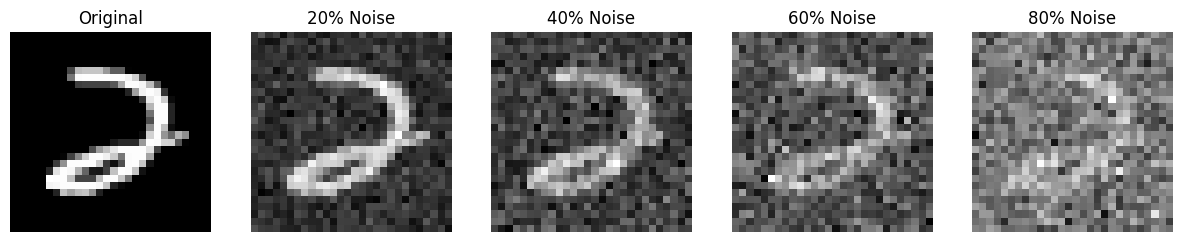

'\n# Try a non-linear noise schedule\nbeta_alt = torch.linspace(beta_start, beta_end, n_steps)**2\nalpha_alt = 1 - beta_alt\nalpha_bar_alt = torch.cumprod(alpha_alt, dim=0)\n# How would this affect the diffusion process?\n'

In [16]:
def show_noise_progression(image, num_steps=5):
    """
    Visualize how an image gets progressively noisier in the diffusion process.

    Args:
        image (torch.Tensor): Original clean image [C, H, W]
        num_steps (int): Number of noise levels to show
    """
    plt.figure(figsize=(15, 3))

    # Show original image
    plt.subplot(1, num_steps, 1)
    if IMG_CH == 1:
        plt.imshow(image[0].cpu(), cmap='gray')
    else:
        img = image.permute(1, 2, 0).cpu()
        if img.min() < 0:
            img = (img + 1) / 2
        plt.imshow(img)
    plt.title('Original')
    plt.axis('off')

    # Show progressively noisier versions
    for i in range(1, num_steps):
        t_idx = int((i/num_steps) * n_steps)
        t = torch.tensor([t_idx]).to(device)

        noisy_image, _ = add_noise(image.unsqueeze(0), t)

        plt.subplot(1, num_steps, i+1)
        if IMG_CH == 1:
            plt.imshow(noisy_image[0][0].cpu(), cmap='gray')
        else:
            img = noisy_image[0].permute(1, 2, 0).cpu()
            if img.min() < 0:
                img = (img + 1) / 2
            plt.imshow(img)
        plt.title(f'{int((i/num_steps) * 100)}% Noise')
        plt.axis('off')
    plt.show()

# Corrected: train_loader instead of train_dataloader
sample_batch = next(iter(train_loader))
sample_image = sample_batch[0][0].to(device)
show_noise_progression(sample_image)

"""
# Try a non-linear noise schedule
beta_alt = torch.linspace(beta_start, beta_end, n_steps)**2
alpha_alt = 1 - beta_alt
alpha_bar_alt = torch.cumprod(alpha_alt, dim=0)
# How would this affect the diffusion process?
"""

## Step 5: Training Our Model

Now we'll teach our AI to generate images. This process:
1. Takes a clear image
2. Adds random noise to it
3. Asks our AI to predict what noise was added
4. Helps our AI learn from its mistakes

This will take a while, but we'll see progress as it learns!

In [36]:
# Create our model and move it to GPU if available
model = UNet(
    T=n_steps,
    img_ch=IMG_CH,
    img_size=IMG_SIZE,
    down_chs=(32, 64, 128),
    t_embed_dim=8,
    c_embed_dim=N_CLASSES
).to(device)

# Print model summary
print(f"\n{'='*50}")
print(f"MODEL ARCHITECTURE SUMMARY")
print(f"{'='*50}")
print(f"Input resolution: {IMG_SIZE}x{IMG_SIZE}")
print(f"Input channels: {IMG_CH}")
print(f"Time steps: {n_steps}")
print(f"Condition classes: {N_CLASSES}")
print(f"GPU acceleration: {'Yes' if device.type == 'cuda' else 'No'}")

# Count and display model parameters
def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

total_params, trainable_params = count_parameters(model)
estimated_memory_mb = (total_params * 4) / (1024 ** 2)

print(f"\nTotal parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Estimated model size: {estimated_memory_mb:.2f} MB")

# Verify data ranges and integrity
def check_data_ranges(loader, name, num_batches=3):
    print(f"\n{name} data validation:")
    for i, (images, labels) in enumerate(loader):
        if i >= num_batches:
            break
        print(f"  Batch {i+1}: shape={images.shape}, "
              f"min={images.min():.3f}, "
              f"max={images.max():.3f}, "
              f"labels={labels.unique().tolist()}")

check_data_ranges(train_loader, "Training")
check_data_ranges(val_loader, "Validation")

# Set up optimizer
initial_lr = 0.001
weight_decay = 1e-5

optimizer = Adam(
    model.parameters(),
    lr=initial_lr,
    weight_decay=weight_decay
)

# Learning rate scheduler (verbose removed - not supported in newer PyTorch)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5,
    min_lr=1e-6
)

print(f"\n✅ Optimizer: Adam (lr={initial_lr}, weight_decay={weight_decay})")
print(f"✅ Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)")


Created DownBlock: in_chs=32, out_chs=64, spatial_reduction=2x
Created DownBlock: in_chs=64, out_chs=128, spatial_reduction=2x
Created UpBlock: in_chs=128, out_chs=64, spatial_increase=2x
Created UpBlock: in_chs=64, out_chs=32, spatial_increase=2x
Created UNet with 3 scale levels
Channel dimensions: (32, 64, 128)

MODEL ARCHITECTURE SUMMARY
Input resolution: 28x28
Input channels: 1
Time steps: 100
Condition classes: 10
GPU acceleration: Yes

Total parameters:     1,494,065
Trainable parameters: 1,494,065
Estimated model size: 5.70 MB

Training data validation:
  Batch 1: shape=torch.Size([64, 1, 28, 28]), min=-1.000, max=1.000, labels=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
  Batch 2: shape=torch.Size([64, 1, 28, 28]), min=-1.000, max=1.000, labels=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
  Batch 3: shape=torch.Size([64, 1, 28, 28]), min=-1.000, max=1.000, labels=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

Validation data validation:
  Batch 1: shape=torch.Size([64, 1, 28, 28]), min=-1.000, max=1.000, labels=[0, 1, 

In [18]:
# Define helper functions needed for training and evaluation
def validate_model_parameters(model):
    """
    Counts model parameters and estimates memory usage.
    """
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    print(f"Total parameters: {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}")

    # Estimate memory requirements (very approximate)
    param_memory = total_params * 4 / (1024 ** 2)  # MB for params (float32)
    grad_memory = trainable_params * 4 / (1024 ** 2)  # MB for gradients
    buffer_memory = param_memory * 2  # Optimizer state, forward activations, etc.

    print(f"Estimated GPU memory usage: {param_memory + grad_memory + buffer_memory:.1f} MB")

# Define helper functions for verifying data ranges
def verify_data_range(dataloader, name="Dataset"):
    """
    Verifies the range and integrity of the data.
    """
    batch = next(iter(dataloader))[0]
    print(f"\n{name} range check:")
    print(f"Shape: {batch.shape}")
    print(f"Data type: {batch.dtype}")
    print(f"Min value: {batch.min().item():.2f}")
    print(f"Max value: {batch.max().item():.2f}")
    print(f"Contains NaN: {torch.isnan(batch).any().item()}")
    print(f"Contains Inf: {torch.isinf(batch).any().item()}")

# Define helper functions for generating samples during training
def generate_samples(model, n_samples=10):
    """
    Generates sample images using the model for visualization during training.
    """
    model.eval()
    with torch.no_grad():
        # Generate digits 0-9 for visualization
        samples = []
        for digit in range(min(n_samples, 10)):
            # Start with random noise
            x = torch.randn(1, IMG_CH, IMG_SIZE, IMG_SIZE).to(device)

            # Set up conditioning for the digit
            c = torch.tensor([digit]).to(device)
            c_one_hot = F.one_hot(c, N_CLASSES).float().to(device)
            c_mask = torch.ones_like(c.unsqueeze(-1)).to(device)

            # Remove noise step by step
            for t in range(n_steps-1, -1, -1):
                t_batch = torch.full((1,), t).to(device)
                x = remove_noise(x, t_batch, model, c_one_hot, c_mask)

            samples.append(x)

        # Combine samples and display
        samples = torch.cat(samples, dim=0)
        grid = make_grid(samples, nrow=min(n_samples, 5), normalize=True)

        plt.figure(figsize=(10, 4))

        # Display based on channel configuration
        if IMG_CH == 1:
            plt.imshow(grid[0].cpu(), cmap='gray')
        else:
            plt.imshow(grid.permute(1, 2, 0).cpu())

        plt.axis('off')
        plt.title('Generated Samples')
        plt.show()

# Define helper functions for safely saving models
def safe_save_model(model, path, optimizer=None, epoch=None, best_loss=None):
    """
    Safely saves model with error handling and backup.
    """
    try:
        # Create a dictionary with all the elements to save
        save_dict = {
            'model_state_dict': model.state_dict(),
        }

        # Add optional elements if provided
        if optimizer is not None:
            save_dict['optimizer_state_dict'] = optimizer.state_dict()
        if epoch is not None:
            save_dict['epoch'] = epoch
        if best_loss is not None:
            save_dict['best_loss'] = best_loss

        # Create a backup of previous checkpoint if it exists
        if os.path.exists(path):
            backup_path = path + '.backup'
            try:
                os.replace(path, backup_path)
                print(f"Created backup at {backup_path}")
            except Exception as e:
                print(f"Warning: Could not create backup - {e}")

        # Save the new checkpoint
        torch.save(save_dict, path)
        print(f"Model successfully saved to {path}")

    except Exception as e:
        print(f"Error saving model: {e}")
        print("Attempting emergency save...")

        try:
            emergency_path = path + '.emergency'
            torch.save(model.state_dict(), emergency_path)
            print(f"Emergency save successful: {emergency_path}")
        except:
            print("Emergency save failed. Could not save model.")

In [19]:
#  Implementation of the training step function
def train_step(x, c):
    """
    Performs a single training step for the diffusion model.

    This function:
    1. Prepares class conditioning
    2. Samples random timesteps for each image
    3. Adds corresponding noise to the images
    4. Asks the model to predict the noise
    5. Calculates the loss between predicted and actual noise

    Args:
        x (torch.Tensor): Batch of clean images [batch_size, channels, height, width]
        c (torch.Tensor): Batch of class labels [batch_size]

    Returns:
        torch.Tensor: Mean squared error loss value
    """
    # Convert labels to one-hot encoding
    c_one_hot = F.one_hot(c, N_CLASSES).float().to(device)

    # Conditioning mask (all ones for standard training)
    c_mask = torch.ones_like(c.unsqueeze(-1)).to(device)

    # Pick random timesteps for each image in the batch
    t = torch.randint(0, n_steps, (x.shape[0],)).to(device)

    # Add noise to images using forward diffusion
    x_t, noise = add_noise(x, t)

    # Model predicts the noise that was added
    predicted_noise = model(x_t, t, c_one_hot, c_mask)

    # MSE loss between predicted and actual noise
    loss = F.mse_loss(predicted_noise, noise)

    return loss

In [26]:
class UpBlock(nn.Module):
    def __init__(self, in_chs, out_chs, group_size):
        super().__init__()

        # This UpBlock definition is now redundant after the correction to `30RKz2eyBNgx`.
        # It's recommended to keep only one definition for clarity.
        # This cell can be deleted or commented out after `30RKz2eyBNgx` is updated and UNet is re-instantiated.

        # ConvTranspose2d upsample: input is 2*in_chs due to skip concatenation
        self.upsample = nn.ConvTranspose2d(in_chs, out_chs, kernel_size=2, stride=2)

        # Two conv blocks to process the upsampled features
        self.conv = nn.Sequential(
            GELUConvBlock(out_chs * 2, out_chs, group_size),
            GELUConvBlock(out_chs, out_chs, group_size)
        )

        print(f"Created UpBlock: in_chs={in_chs}, out_chs={out_chs}, spatial_increase=2x")

    def forward(self, x, skip):
        # 1. Upsample first
        x = self.upsample(x)              # (B, out_chs, H*2, W*2)
        # 2. Concatenate skip connection
        x = torch.cat([x, skip], dim=1)  # (B, out_chs*2, H*2, W*2)
        # 3. Process features
        x = self.conv(x)                  # (B, out_chs, H*2, W*2)
        return x



STARTING TRAINING

Epoch 1/30
--------------------
  Step 0/750, Loss: 1.1786
  Step 100/750, Loss: 0.1259
  Step 200/750, Loss: 0.0956
  Step 300/750, Loss: 0.0911
  Step 400/750, Loss: 0.0854
  Step 500/750, Loss: 0.0816
  Step 600/750, Loss: 0.0753
  Step 700/750, Loss: 0.0809
Training - Epoch 1 average loss: 0.1055
Validation - Epoch 1 average loss: 0.0772


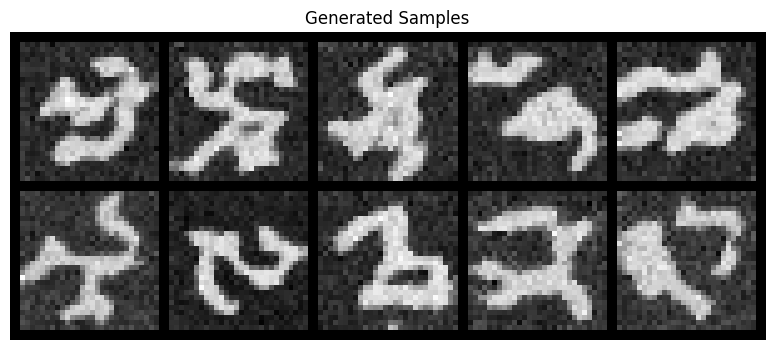

Created backup at best_diffusion_model.pt.backup
Model successfully saved to best_diffusion_model.pt
✓ New best model saved! (Val Loss: 0.0772)

Epoch 2/30
--------------------
  Step 0/750, Loss: 0.0793
  Step 100/750, Loss: 0.0672
  Step 200/750, Loss: 0.0690
  Step 300/750, Loss: 0.0606
  Step 400/750, Loss: 0.0860
  Step 500/750, Loss: 0.0747
  Step 600/750, Loss: 0.0726
  Step 700/750, Loss: 0.0542
Training - Epoch 2 average loss: 0.0718
Validation - Epoch 2 average loss: 0.0688
Created backup at best_diffusion_model.pt.backup
Model successfully saved to best_diffusion_model.pt
✓ New best model saved! (Val Loss: 0.0688)

Epoch 3/30
--------------------
  Step 0/750, Loss: 0.0562
  Step 100/750, Loss: 0.0582
  Step 200/750, Loss: 0.0670
  Step 300/750, Loss: 0.0685
  Step 400/750, Loss: 0.0787
  Step 500/750, Loss: 0.0819
  Step 600/750, Loss: 0.0657
  Step 700/750, Loss: 0.0639
Training - Epoch 3 average loss: 0.0675
Validation - Epoch 3 average loss: 0.0690


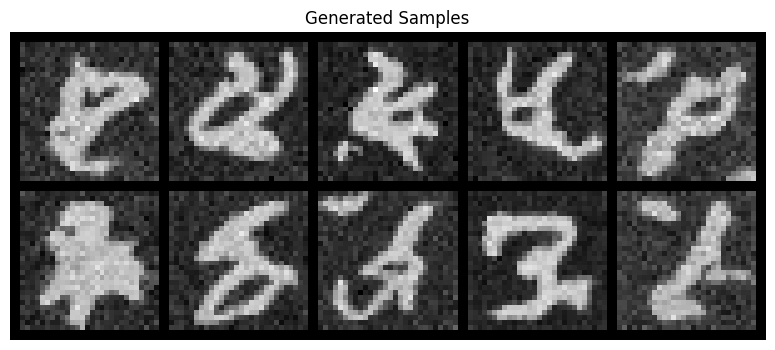


Epoch 4/30
--------------------
  Step 0/750, Loss: 0.0663
  Step 100/750, Loss: 0.0608
  Step 200/750, Loss: 0.0695
  Step 300/750, Loss: 0.0618
  Step 400/750, Loss: 0.0816
  Step 500/750, Loss: 0.0682
  Step 600/750, Loss: 0.0659
  Step 700/750, Loss: 0.0703
Training - Epoch 4 average loss: 0.0659
Validation - Epoch 4 average loss: 0.0632
Created backup at best_diffusion_model.pt.backup
Model successfully saved to best_diffusion_model.pt
✓ New best model saved! (Val Loss: 0.0632)

Epoch 5/30
--------------------
  Step 0/750, Loss: 0.0678
  Step 100/750, Loss: 0.0710
  Step 200/750, Loss: 0.0692
  Step 300/750, Loss: 0.0604
  Step 400/750, Loss: 0.0653
  Step 500/750, Loss: 0.0558
  Step 600/750, Loss: 0.0668
  Step 700/750, Loss: 0.0641
Training - Epoch 5 average loss: 0.0639
Validation - Epoch 5 average loss: 0.0641


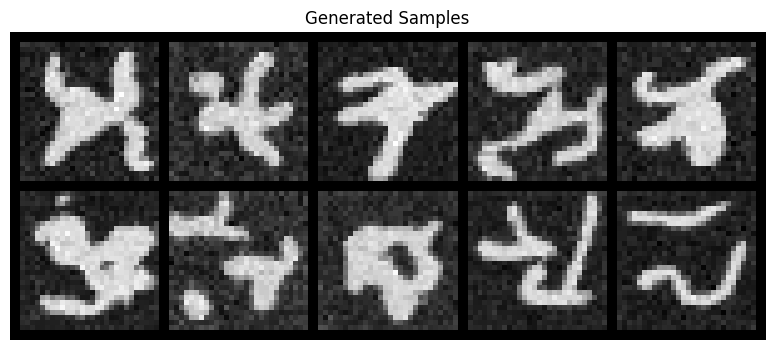


Epoch 6/30
--------------------
  Step 0/750, Loss: 0.0558
  Step 100/750, Loss: 0.0793
  Step 200/750, Loss: 0.0598
  Step 300/750, Loss: 0.0634
  Step 400/750, Loss: 0.0604
  Step 500/750, Loss: 0.0618
  Step 600/750, Loss: 0.0649
  Step 700/750, Loss: 0.0534
Training - Epoch 6 average loss: 0.0627
Validation - Epoch 6 average loss: 0.0611
Created backup at best_diffusion_model.pt.backup
Model successfully saved to best_diffusion_model.pt
✓ New best model saved! (Val Loss: 0.0611)

Epoch 7/30
--------------------
  Step 0/750, Loss: 0.0582
  Step 100/750, Loss: 0.0680
  Step 200/750, Loss: 0.0672
  Step 300/750, Loss: 0.0591
  Step 400/750, Loss: 0.0691
  Step 500/750, Loss: 0.0640
  Step 600/750, Loss: 0.0666
  Step 700/750, Loss: 0.0554
Training - Epoch 7 average loss: 0.0620
Validation - Epoch 7 average loss: 0.0613


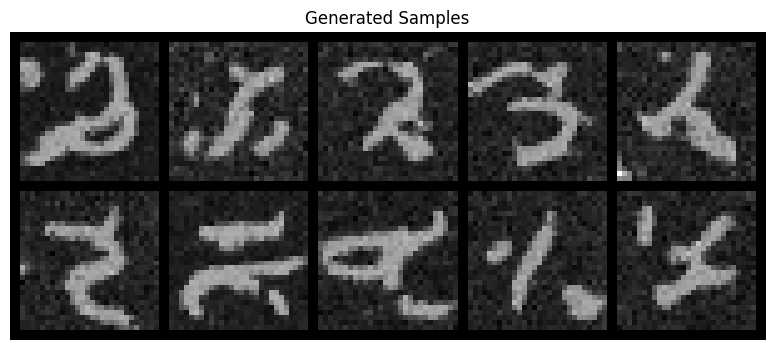


Epoch 8/30
--------------------
  Step 0/750, Loss: 0.0610
  Step 100/750, Loss: 0.0590
  Step 200/750, Loss: 0.0607
  Step 300/750, Loss: 0.0543
  Step 400/750, Loss: 0.0623
  Step 500/750, Loss: 0.0578
  Step 600/750, Loss: 0.0667
  Step 700/750, Loss: 0.0562
Training - Epoch 8 average loss: 0.0615
Validation - Epoch 8 average loss: 0.0616

Epoch 9/30
--------------------
  Step 0/750, Loss: 0.0567
  Step 100/750, Loss: 0.0596
  Step 200/750, Loss: 0.0658
  Step 300/750, Loss: 0.0616
  Step 400/750, Loss: 0.0524
  Step 500/750, Loss: 0.0623
  Step 600/750, Loss: 0.0566
  Step 700/750, Loss: 0.0601
Training - Epoch 9 average loss: 0.0609
Validation - Epoch 9 average loss: 0.0606


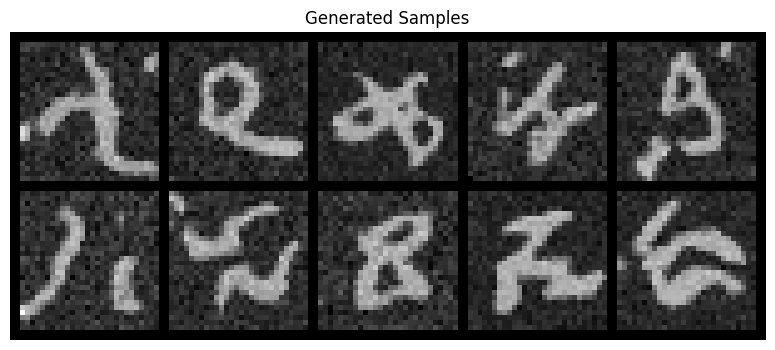

Created backup at best_diffusion_model.pt.backup
Model successfully saved to best_diffusion_model.pt
✓ New best model saved! (Val Loss: 0.0606)

Epoch 10/30
--------------------
  Step 0/750, Loss: 0.0695
  Step 100/750, Loss: 0.0547
  Step 200/750, Loss: 0.0656
  Step 300/750, Loss: 0.0621
  Step 400/750, Loss: 0.0580
  Step 500/750, Loss: 0.0523
  Step 600/750, Loss: 0.0595
  Step 700/750, Loss: 0.0537
Training - Epoch 10 average loss: 0.0605
Validation - Epoch 10 average loss: 0.0598
Created backup at best_diffusion_model.pt.backup
Model successfully saved to best_diffusion_model.pt
✓ New best model saved! (Val Loss: 0.0598)

Epoch 11/30
--------------------
  Step 0/750, Loss: 0.0565
  Step 100/750, Loss: 0.0576
  Step 200/750, Loss: 0.0657
  Step 300/750, Loss: 0.0605
  Step 400/750, Loss: 0.0577
  Step 500/750, Loss: 0.0645
  Step 600/750, Loss: 0.0697
  Step 700/750, Loss: 0.0723
Training - Epoch 11 average loss: 0.0601
Validation - Epoch 11 average loss: 0.0595


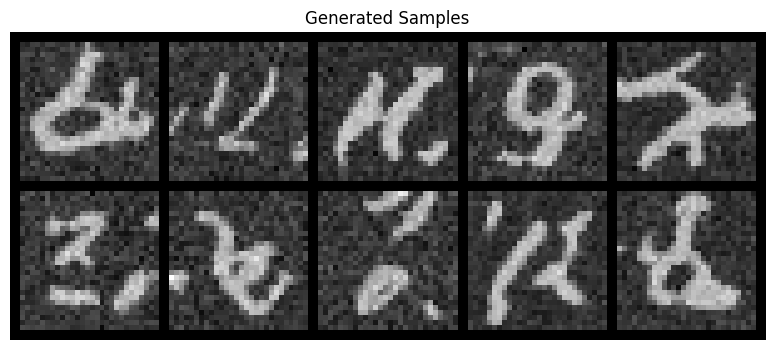

Created backup at best_diffusion_model.pt.backup
Model successfully saved to best_diffusion_model.pt
✓ New best model saved! (Val Loss: 0.0595)

Epoch 12/30
--------------------
  Step 0/750, Loss: 0.0645
  Step 100/750, Loss: 0.0686
  Step 200/750, Loss: 0.0634
  Step 300/750, Loss: 0.0582
  Step 400/750, Loss: 0.0620
  Step 500/750, Loss: 0.0599
  Step 600/750, Loss: 0.0649
  Step 700/750, Loss: 0.0622
Training - Epoch 12 average loss: 0.0595
Validation - Epoch 12 average loss: 0.0610

Epoch 13/30
--------------------
  Step 0/750, Loss: 0.0644
  Step 100/750, Loss: 0.0617
  Step 200/750, Loss: 0.0551
  Step 300/750, Loss: 0.0698
  Step 400/750, Loss: 0.0666
  Step 500/750, Loss: 0.0523
  Step 600/750, Loss: 0.0624
  Step 700/750, Loss: 0.0644
Training - Epoch 13 average loss: 0.0593
Validation - Epoch 13 average loss: 0.0590


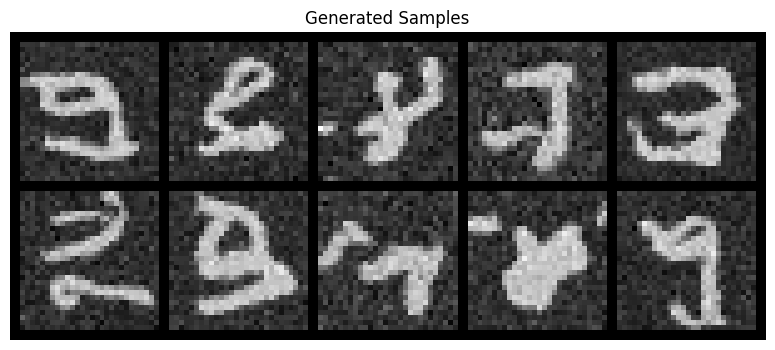

Created backup at best_diffusion_model.pt.backup
Model successfully saved to best_diffusion_model.pt
✓ New best model saved! (Val Loss: 0.0590)

Epoch 14/30
--------------------
  Step 0/750, Loss: 0.0612
  Step 100/750, Loss: 0.0673
  Step 200/750, Loss: 0.0526
  Step 300/750, Loss: 0.0640
  Step 400/750, Loss: 0.0589
  Step 500/750, Loss: 0.0471
  Step 600/750, Loss: 0.0550
  Step 700/750, Loss: 0.0560
Training - Epoch 14 average loss: 0.0591
Validation - Epoch 14 average loss: 0.0590
Created backup at best_diffusion_model.pt.backup
Model successfully saved to best_diffusion_model.pt
✓ New best model saved! (Val Loss: 0.0590)

Epoch 15/30
--------------------
  Step 0/750, Loss: 0.0584
  Step 100/750, Loss: 0.0546
  Step 200/750, Loss: 0.0634
  Step 300/750, Loss: 0.0573
  Step 400/750, Loss: 0.0606
  Step 500/750, Loss: 0.0560
  Step 600/750, Loss: 0.0605
  Step 700/750, Loss: 0.0564
Training - Epoch 15 average loss: 0.0590
Validation - Epoch 15 average loss: 0.0579


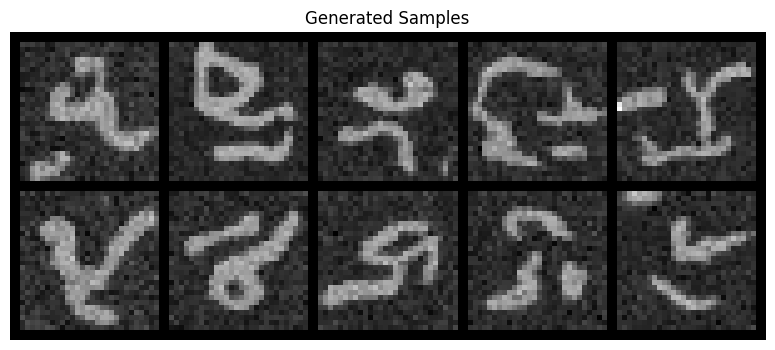

Created backup at best_diffusion_model.pt.backup
Model successfully saved to best_diffusion_model.pt
✓ New best model saved! (Val Loss: 0.0579)

Epoch 16/30
--------------------
  Step 0/750, Loss: 0.0537
  Step 100/750, Loss: 0.0577
  Step 200/750, Loss: 0.0557
  Step 300/750, Loss: 0.0730
  Step 400/750, Loss: 0.0660
  Step 500/750, Loss: 0.0564
  Step 600/750, Loss: 0.0595
  Step 700/750, Loss: 0.0697
Training - Epoch 16 average loss: 0.0584
Validation - Epoch 16 average loss: 0.0574
Created backup at best_diffusion_model.pt.backup
Model successfully saved to best_diffusion_model.pt
✓ New best model saved! (Val Loss: 0.0574)

Epoch 17/30
--------------------
  Step 0/750, Loss: 0.0602
  Step 100/750, Loss: 0.0602
  Step 200/750, Loss: 0.0524
  Step 300/750, Loss: 0.0605
  Step 400/750, Loss: 0.0519
  Step 500/750, Loss: 0.0627
  Step 600/750, Loss: 0.0522
  Step 700/750, Loss: 0.0637
Training - Epoch 17 average loss: 0.0588
Validation - Epoch 17 average loss: 0.0581


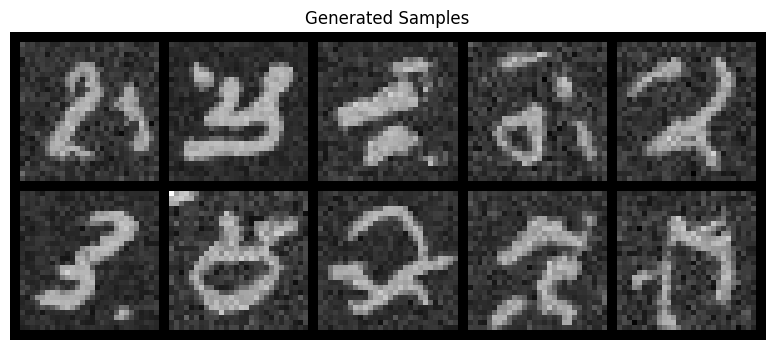


Epoch 18/30
--------------------
  Step 0/750, Loss: 0.0606
  Step 100/750, Loss: 0.0595
  Step 200/750, Loss: 0.0572
  Step 300/750, Loss: 0.0629
  Step 400/750, Loss: 0.0547
  Step 500/750, Loss: 0.0547
  Step 600/750, Loss: 0.0598
  Step 700/750, Loss: 0.0663
Training - Epoch 18 average loss: 0.0580
Validation - Epoch 18 average loss: 0.0584

Epoch 19/30
--------------------
  Step 0/750, Loss: 0.0550
  Step 100/750, Loss: 0.0501
  Step 200/750, Loss: 0.0578
  Step 300/750, Loss: 0.0592
  Step 400/750, Loss: 0.0602
  Step 500/750, Loss: 0.0567
  Step 600/750, Loss: 0.0607
  Step 700/750, Loss: 0.0606
Training - Epoch 19 average loss: 0.0582
Validation - Epoch 19 average loss: 0.0589


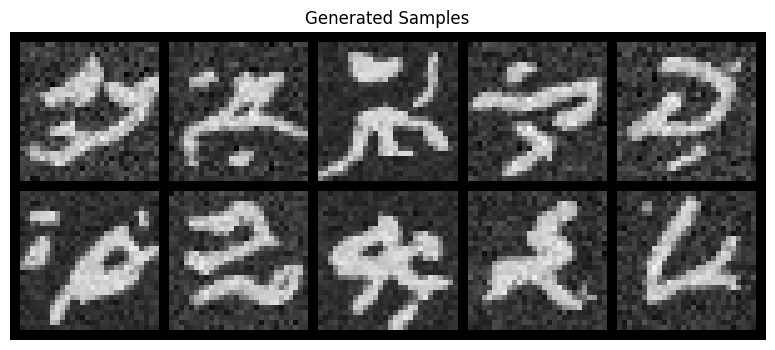


Epoch 20/30
--------------------
  Step 0/750, Loss: 0.0631
  Step 100/750, Loss: 0.0542
  Step 200/750, Loss: 0.0563
  Step 300/750, Loss: 0.0477
  Step 400/750, Loss: 0.0641
  Step 500/750, Loss: 0.0524
  Step 600/750, Loss: 0.0562
  Step 700/750, Loss: 0.0605
Training - Epoch 20 average loss: 0.0579
Validation - Epoch 20 average loss: 0.0574

Epoch 21/30
--------------------
  Step 0/750, Loss: 0.0593
  Step 100/750, Loss: 0.0539
  Step 200/750, Loss: 0.0595
  Step 300/750, Loss: 0.0662
  Step 400/750, Loss: 0.0527
  Step 500/750, Loss: 0.0594
  Step 600/750, Loss: 0.0492
  Step 700/750, Loss: 0.0530
Training - Epoch 21 average loss: 0.0581
Validation - Epoch 21 average loss: 0.0576


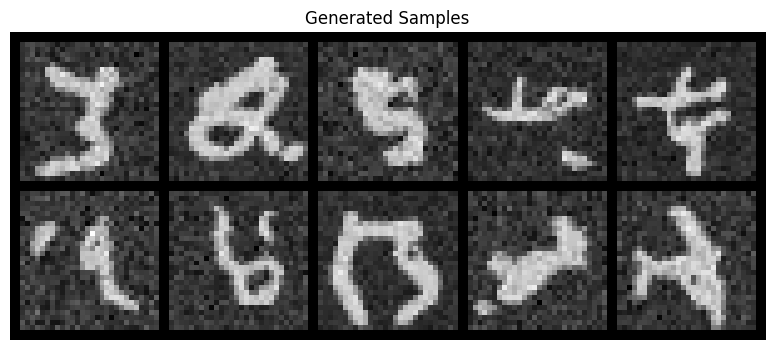


Epoch 22/30
--------------------
  Step 0/750, Loss: 0.0472
  Step 100/750, Loss: 0.0540
  Step 200/750, Loss: 0.0601
  Step 300/750, Loss: 0.0621
  Step 400/750, Loss: 0.0590
  Step 500/750, Loss: 0.0495
  Step 600/750, Loss: 0.0604
  Step 700/750, Loss: 0.0562
Training - Epoch 22 average loss: 0.0575
Validation - Epoch 22 average loss: 0.0580

Epoch 23/30
--------------------
  Step 0/750, Loss: 0.0587
  Step 100/750, Loss: 0.0629
  Step 200/750, Loss: 0.0563
  Step 300/750, Loss: 0.0576
  Step 400/750, Loss: 0.0650
  Step 500/750, Loss: 0.0519
  Step 600/750, Loss: 0.0541
  Step 700/750, Loss: 0.0487
Training - Epoch 23 average loss: 0.0564
Validation - Epoch 23 average loss: 0.0558


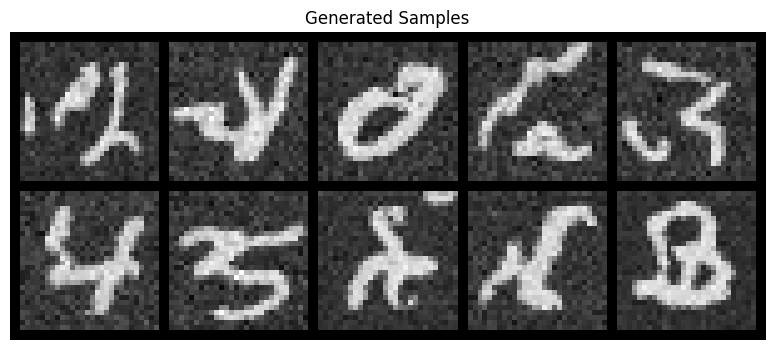

Created backup at best_diffusion_model.pt.backup
Model successfully saved to best_diffusion_model.pt
✓ New best model saved! (Val Loss: 0.0558)

Epoch 24/30
--------------------
  Step 0/750, Loss: 0.0517
  Step 100/750, Loss: 0.0598
  Step 200/750, Loss: 0.0549
  Step 300/750, Loss: 0.0508
  Step 400/750, Loss: 0.0549
  Step 500/750, Loss: 0.0579
  Step 600/750, Loss: 0.0517
  Step 700/750, Loss: 0.0562
Training - Epoch 24 average loss: 0.0561
Validation - Epoch 24 average loss: 0.0567

Epoch 25/30
--------------------
  Step 0/750, Loss: 0.0514
  Step 100/750, Loss: 0.0509
  Step 200/750, Loss: 0.0621
  Step 300/750, Loss: 0.0542
  Step 400/750, Loss: 0.0523
  Step 500/750, Loss: 0.0574
  Step 600/750, Loss: 0.0515
  Step 700/750, Loss: 0.0525
Training - Epoch 25 average loss: 0.0563
Validation - Epoch 25 average loss: 0.0566


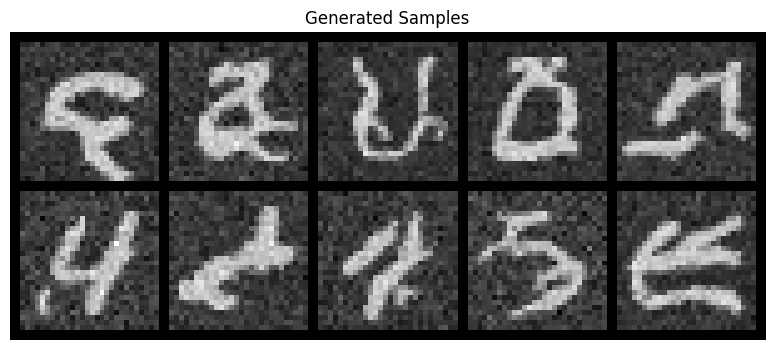


Epoch 26/30
--------------------
  Step 0/750, Loss: 0.0638
  Step 100/750, Loss: 0.0520
  Step 200/750, Loss: 0.0491
  Step 300/750, Loss: 0.0577
  Step 400/750, Loss: 0.0583
  Step 500/750, Loss: 0.0533
  Step 600/750, Loss: 0.0514
  Step 700/750, Loss: 0.0509
Training - Epoch 26 average loss: 0.0560
Validation - Epoch 26 average loss: 0.0552
Created backup at best_diffusion_model.pt.backup
Model successfully saved to best_diffusion_model.pt
✓ New best model saved! (Val Loss: 0.0552)

Epoch 27/30
--------------------
  Step 0/750, Loss: 0.0574
  Step 100/750, Loss: 0.0518
  Step 200/750, Loss: 0.0627
  Step 300/750, Loss: 0.0488
  Step 400/750, Loss: 0.0597
  Step 500/750, Loss: 0.0625
  Step 600/750, Loss: 0.0556
  Step 700/750, Loss: 0.0572
Training - Epoch 27 average loss: 0.0563
Validation - Epoch 27 average loss: 0.0567


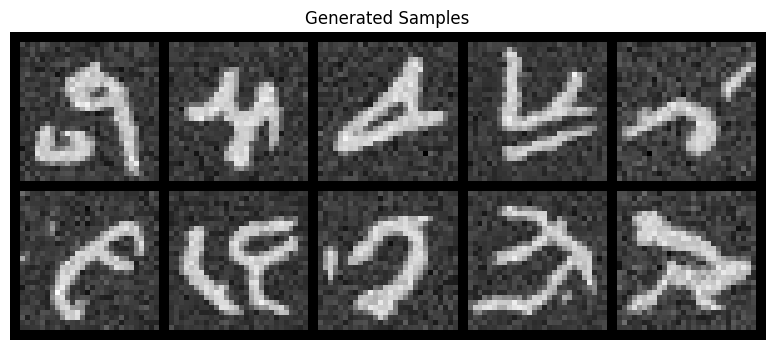


Epoch 28/30
--------------------
  Step 0/750, Loss: 0.0489
  Step 100/750, Loss: 0.0483
  Step 200/750, Loss: 0.0554
  Step 300/750, Loss: 0.0541
  Step 400/750, Loss: 0.0548
  Step 500/750, Loss: 0.0555
  Step 600/750, Loss: 0.0659
  Step 700/750, Loss: 0.0532
Training - Epoch 28 average loss: 0.0558
Validation - Epoch 28 average loss: 0.0560

Epoch 29/30
--------------------
  Step 0/750, Loss: 0.0520
  Step 100/750, Loss: 0.0549
  Step 200/750, Loss: 0.0488
  Step 300/750, Loss: 0.0596
  Step 400/750, Loss: 0.0528
  Step 500/750, Loss: 0.0496
  Step 600/750, Loss: 0.0612
  Step 700/750, Loss: 0.0552
Training - Epoch 29 average loss: 0.0559
Validation - Epoch 29 average loss: 0.0560


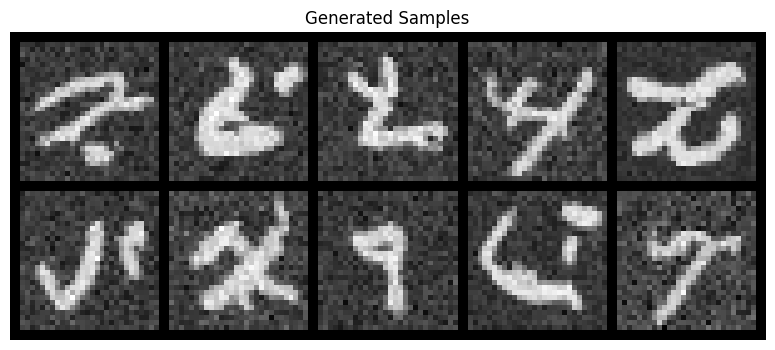


Epoch 30/30
--------------------
  Step 0/750, Loss: 0.0626
  Step 100/750, Loss: 0.0638
  Step 200/750, Loss: 0.0530
  Step 300/750, Loss: 0.0567
  Step 400/750, Loss: 0.0639
  Step 500/750, Loss: 0.0547
  Step 600/750, Loss: 0.0568
  Step 700/750, Loss: 0.0514
Training - Epoch 30 average loss: 0.0560
Validation - Epoch 30 average loss: 0.0559


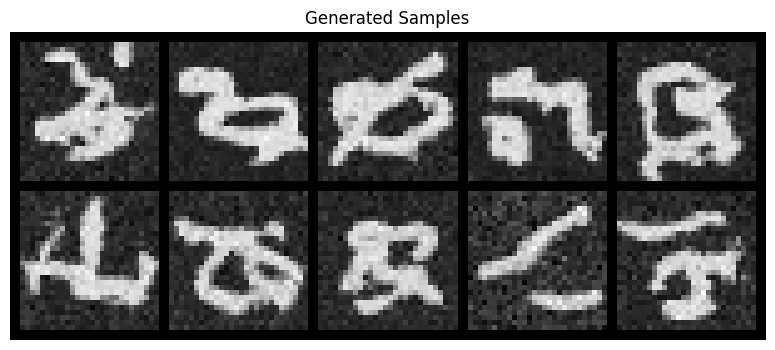


TRAINING COMPLETE
Best validation loss: 0.0552


In [38]:
# Training configuration
early_stopping_patience = 10
gradient_clip_value = 1.0
display_frequency = 100
generate_frequency = 500

# Progress tracking
best_loss = float('inf')
train_losses = []
val_losses = []
no_improve_epochs = 0

print("\n" + "="*50)
print("STARTING TRAINING")
print("="*50)

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print("-" * 20)

    # Training phase
    model.train()
    epoch_losses = []

    for step, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        loss = train_step(images, labels)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=gradient_clip_value)
        optimizer.step()
        epoch_losses.append(loss.item())

        if step % display_frequency == 0:
            print(f"  Step {step}/{len(train_loader)}, Loss: {loss.item():.4f}")

    avg_train_loss = sum(epoch_losses) / len(epoch_losses)
    train_losses.append(avg_train_loss)
    print(f"Training - Epoch {epoch+1} average loss: {avg_train_loss:.4f}")

    # Validation phase
    model.eval()
    val_epoch_losses = []

    with torch.no_grad():
        for val_images, val_labels in val_loader:
            val_images = val_images.to(device)
            val_labels = val_labels.to(device)
            val_loss = train_step(val_images, val_labels)
            val_epoch_losses.append(val_loss.item())

    avg_val_loss = sum(val_epoch_losses) / len(val_epoch_losses)
    val_losses.append(avg_val_loss)
    print(f"Validation - Epoch {epoch+1} average loss: {avg_val_loss:.4f}")

    scheduler.step(avg_val_loss)

    if epoch % 2 == 0 or epoch == EPOCHS - 1:
        generate_samples(model, n_samples=10)

    if avg_val_loss < best_loss:
        best_loss = avg_val_loss
        safe_save_model(model, 'best_diffusion_model.pt', optimizer, epoch, best_loss)
        print(f"✓ New best model saved! (Val Loss: {best_loss:.4f})")
        no_improve_epochs = 0
    else:
        no_improve_epochs += 1

    if no_improve_epochs >= early_stopping_patience:
        print("\nEarly stopping triggered!")
        break

print("\n" + "="*50)
print("TRAINING COMPLETE")
print("="*50)
print(f"Best validation loss: {best_loss:.4f}")
torch.cuda.empty_cache()


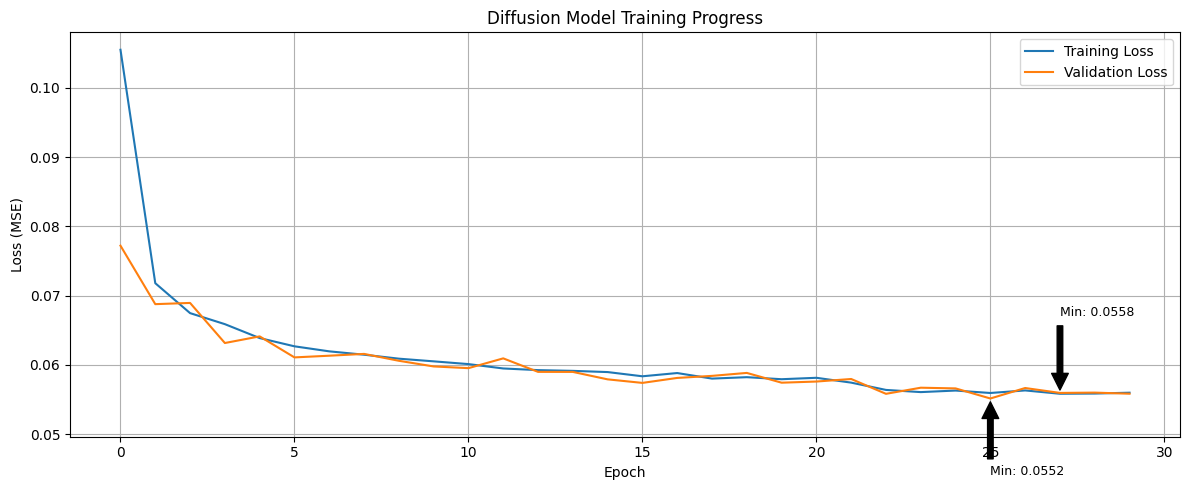


Training Statistics:
------------------------------
Starting training loss:    0.1055
Final training loss:       0.0560
Best training loss:        0.0558
Training loss improvement: 47.1%

Validation Statistics:
------------------------------
Starting validation loss: 0.0772
Final validation loss:    0.0559
Best validation loss:     0.0552


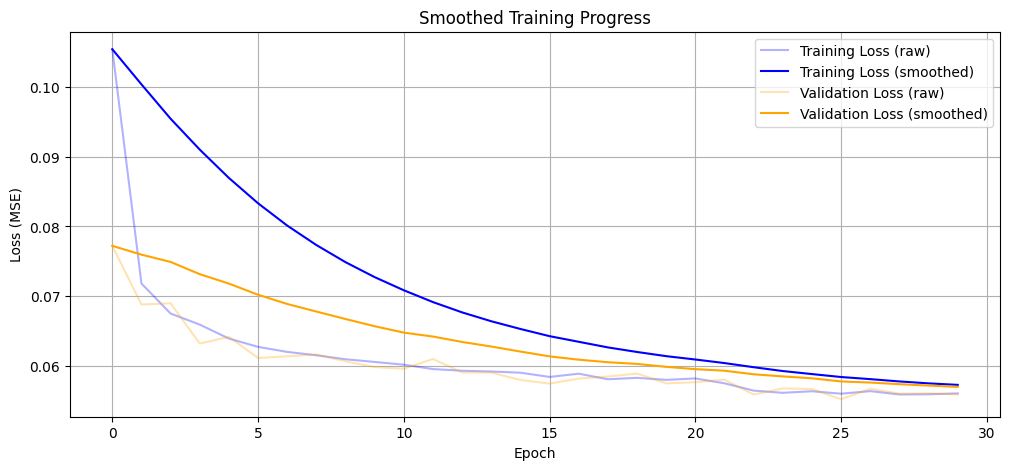

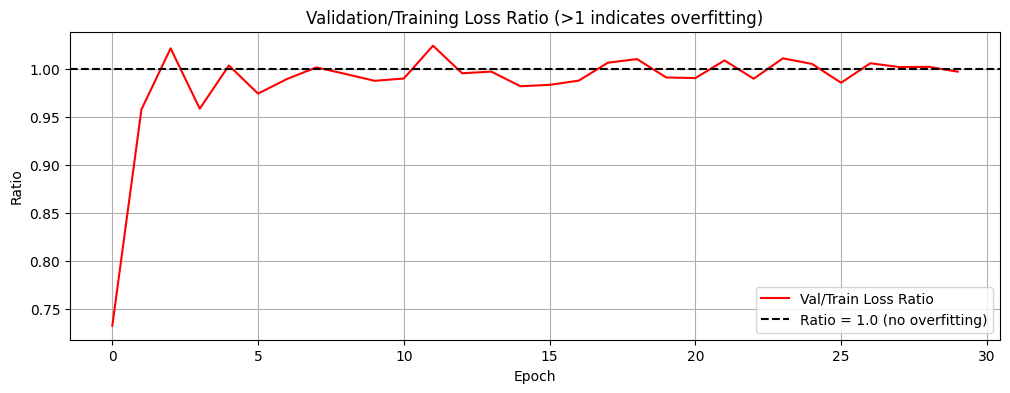

Final ratio: 0.9974
✅ Model is not overfitting


In [41]:
# Plot training progress
plt.figure(figsize=(12, 5))

# Plot training and validation losses for comparison
plt.plot(train_losses, label='Training Loss')
if len(val_losses) > 0:  # Only plot validation if it exists
    plt.plot(val_losses, label='Validation Loss')

# Improve the plot with better labels and styling
plt.title('Diffusion Model Training Progress')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)

# Add annotations for key points
if len(train_losses) > 1:
    min_train_idx = train_losses.index(min(train_losses))
    plt.annotate(f'Min: {min(train_losses):.4f}',
                 xy=(min_train_idx, min(train_losses)),
                 xytext=(min_train_idx, min(train_losses)*1.2),
                 arrowprops=dict(facecolor='black', shrink=0.05),
                 fontsize=9)

# Add validation min point if available
if len(val_losses) > 1:
    min_val_idx = val_losses.index(min(val_losses))
    plt.annotate(f'Min: {min(val_losses):.4f}',
                xy=(min_val_idx, min(val_losses)),
                xytext=(min_val_idx, min(val_losses)*0.8),
                arrowprops=dict(facecolor='black', shrink=0.05),
                fontsize=9)

# Set y-axis to start from 0 or slightly lower than min value
plt.ylim(bottom=max(0, min(min(train_losses) if train_losses else float('inf'),
                          min(val_losses) if val_losses else float('inf'))*0.9))

plt.tight_layout()
plt.show()

# Add statistics summary for students to analyze
print("\nTraining Statistics:")
print("-" * 30)
if train_losses:
    print(f"Starting training loss:    {train_losses[0]:.4f}")
    print(f"Final training loss:       {train_losses[-1]:.4f}")
    print(f"Best training loss:        {min(train_losses):.4f}")
    print(f"Training loss improvement: {((train_losses[0] - min(train_losses)) / train_losses[0] * 100):.1f}%")

if val_losses:
    print("\nValidation Statistics:")
    print("-" * 30)
    print(f"Starting validation loss: {val_losses[0]:.4f}")
    print(f"Final validation loss:    {val_losses[-1]:.4f}")
    print(f"Best validation loss:     {min(val_losses):.4f}")

# STUDENT EXERCISE:
# STUDENT EXERCISE 1: Smoothed version of losses
import numpy as np

def smooth(values, weight=0.85):
    smoothed = []
    last = values[0]
    for v in values:
        smoothed_val = last * weight + (1 - weight) * v
        smoothed.append(smoothed_val)
        last = smoothed_val
    return smoothed

plt.figure(figsize=(12, 5))
plt.plot(train_losses, alpha=0.3, color='blue', label='Training Loss (raw)')
plt.plot(smooth(train_losses), color='blue', label='Training Loss (smoothed)')
plt.plot(val_losses, alpha=0.3, color='orange', label='Validation Loss (raw)')
plt.plot(smooth(val_losses), color='orange', label='Validation Loss (smoothed)')
plt.title('Smoothed Training Progress')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

# STUDENT EXERCISE 2: Ratio of validation to training loss
ratios = [v/t for v, t in zip(val_losses, train_losses)]

plt.figure(figsize=(12, 4))
plt.plot(ratios, color='red', label='Val/Train Loss Ratio')
plt.axhline(y=1.0, color='black', linestyle='--', label='Ratio = 1.0 (no overfitting)')
plt.title('Validation/Training Loss Ratio (>1 indicates overfitting)')
plt.xlabel('Epoch')
plt.ylabel('Ratio')
plt.legend()
plt.grid(True)
plt.show()

print(f"Final ratio: {ratios[-1]:.4f}")
if ratios[-1] <= 1.05:
    print("✅ Model is not overfitting")
else:
    print("⚠️ Model may be overfitting")

## Step 6: Generating New Images

Now that our model is trained, let's generate some new images! We can:
1. Generate specific numbers
2. Generate multiple versions of each number
3. See how the generation process works step by step

Generating 4 versions of number 0...
  Denoising step 19/99 completed
  Denoising step 39/99 completed
  Denoising step 59/99 completed
  Denoising step 79/99 completed
  Denoising step 99/99 completed
Generating 4 versions of number 1...
  Denoising step 19/99 completed
  Denoising step 39/99 completed
  Denoising step 59/99 completed
  Denoising step 79/99 completed
  Denoising step 99/99 completed
Generating 4 versions of number 2...
  Denoising step 19/99 completed
  Denoising step 39/99 completed
  Denoising step 59/99 completed
  Denoising step 79/99 completed
  Denoising step 99/99 completed
Generating 4 versions of number 3...
  Denoising step 19/99 completed
  Denoising step 39/99 completed
  Denoising step 59/99 completed
  Denoising step 79/99 completed
  Denoising step 99/99 completed
Generating 4 versions of number 4...
  Denoising step 19/99 completed
  Denoising step 39/99 completed
  Denoising step 59/99 completed
  Denoising step 79/99 completed
  Denoising step 99/99 

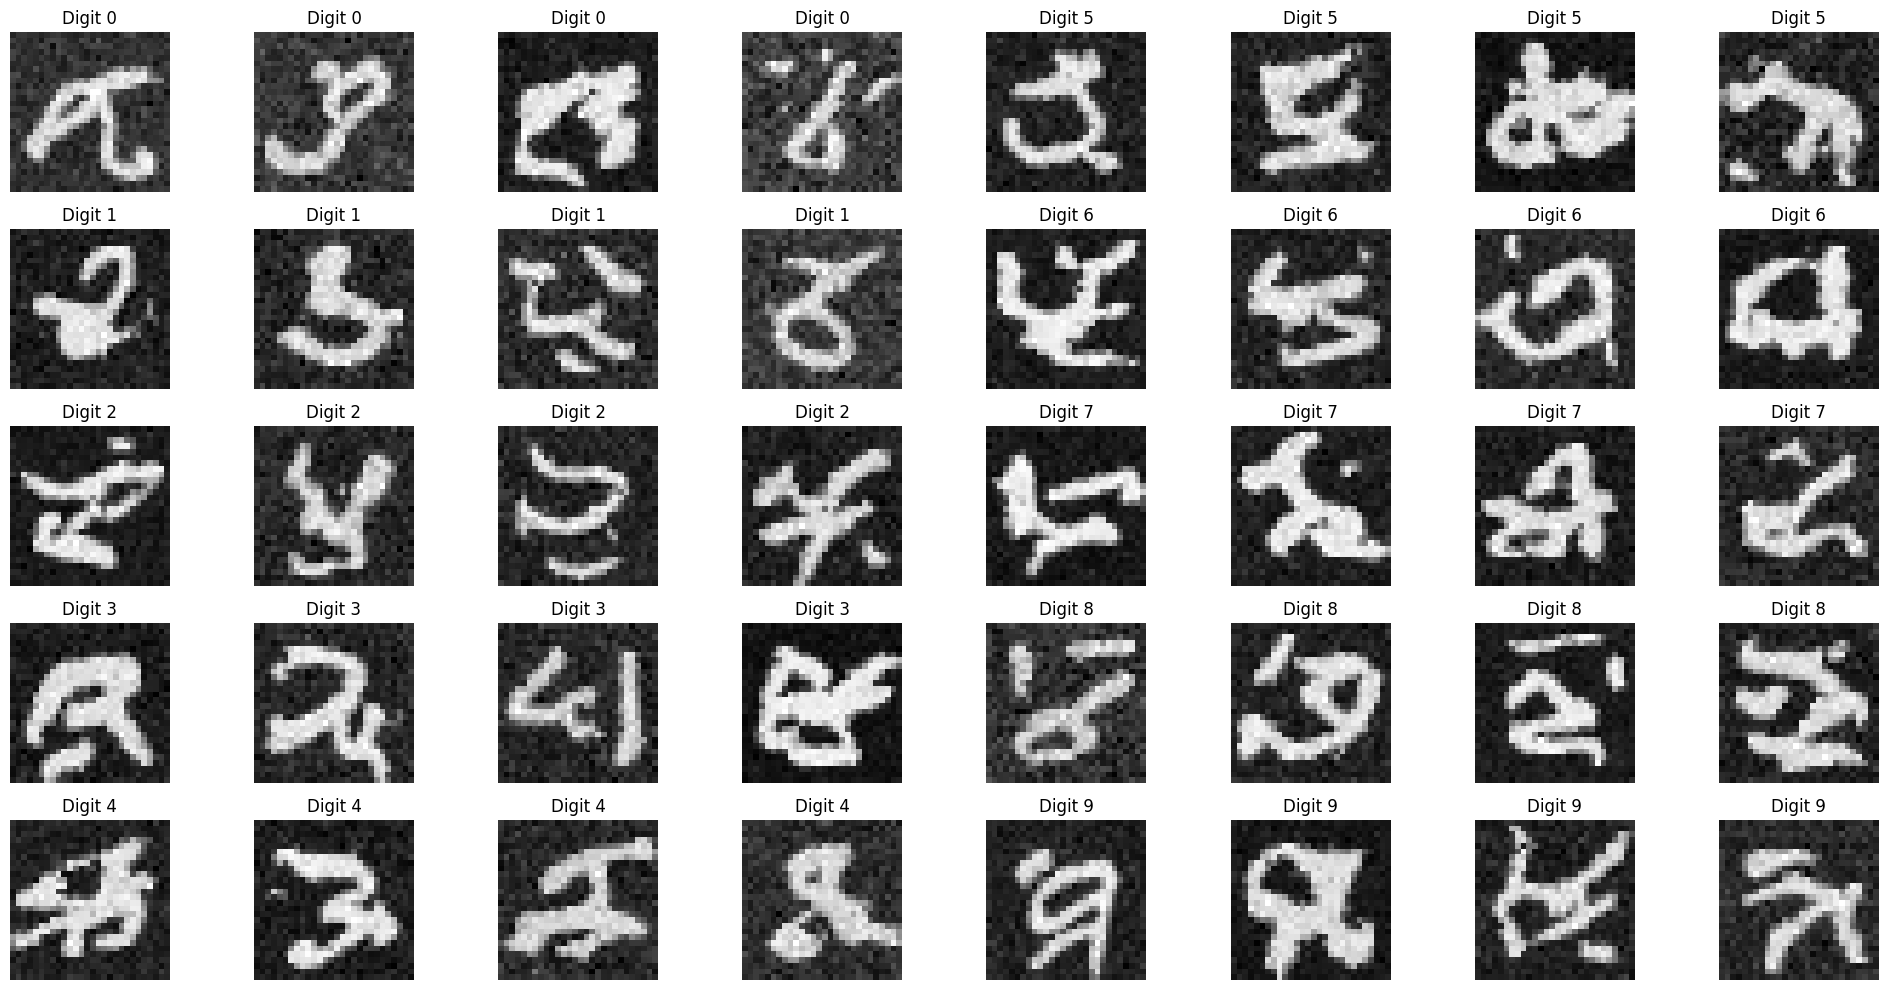


STUDENT ACTIVITY: Generating numbers with different noise seeds
Generating 10 versions of number 7...
  Denoising step 19/99 completed
  Denoising step 39/99 completed
  Denoising step 59/99 completed
  Denoising step 79/99 completed
  Denoising step 99/99 completed


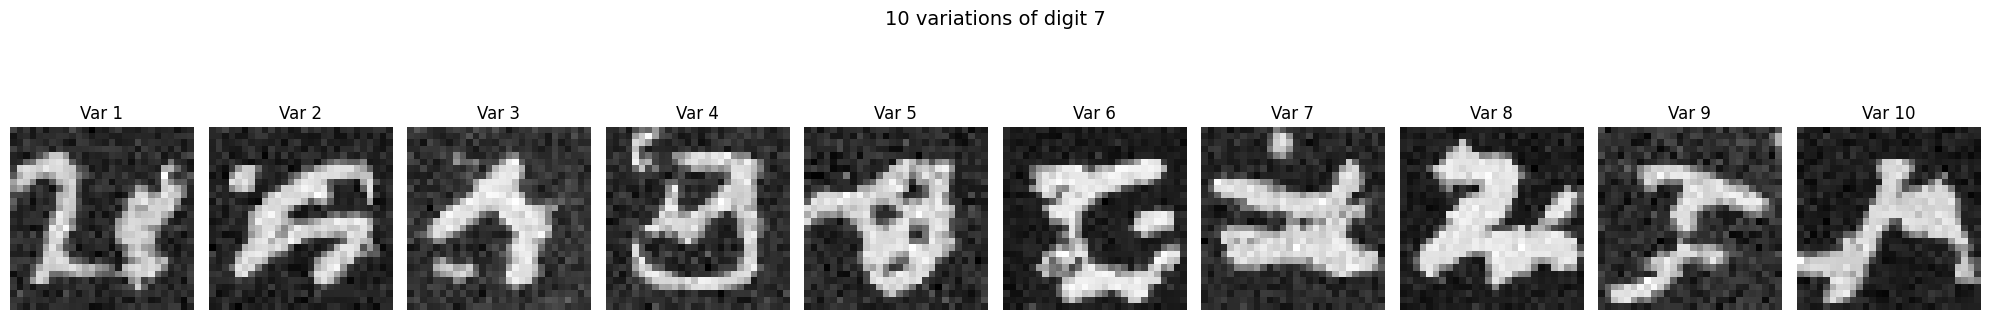

In [42]:
def generate_number(model, number, n_samples=4):
    """
    Generate multiple versions of a specific number using the diffusion model.

    Args:
        model (nn.Module): The trained diffusion model
        number (int): The digit to generate (0-9)
        n_samples (int): Number of variations to generate

    Returns:
        torch.Tensor: Generated images of shape [n_samples, IMG_CH, IMG_SIZE, IMG_SIZE]
    """
    model.eval()
    with torch.no_grad():
        # Start with random noise
        samples = torch.randn(n_samples, IMG_CH, IMG_SIZE, IMG_SIZE).to(device)

        # Set up conditioning
        c = torch.full((n_samples,), number).to(device)
        c_one_hot = F.one_hot(c, N_CLASSES).float().to(device)
        c_mask = torch.ones_like(c.unsqueeze(-1)).to(device)

        print(f"Generating {n_samples} versions of number {number}...")

        # Remove noise step by step
        for t in range(n_steps-1, -1, -1):
            t_batch = torch.full((n_samples,), t).to(device)
            samples = remove_noise(samples, t_batch, model, c_one_hot, c_mask)

            if t % (n_steps // 5) == 0:
                print(f"  Denoising step {n_steps-1-t}/{n_steps-1} completed")

        return samples

# Generate 4 versions of each number
plt.figure(figsize=(20, 10))
for i in range(10):
    samples = generate_number(model, i, n_samples=4)

    for j in range(4):
        plt.subplot(5, 8, (i%5)*8 + (i//5)*4 + j + 1)

        if IMG_CH == 1:
            plt.imshow(samples[j][0].cpu(), cmap='gray')
        else:
            img = samples[j].permute(1, 2, 0).cpu()
            if img.min() < 0:
                img = (img + 1) / 2
            plt.imshow(img)

        plt.title(f'Digit {i}')
        plt.axis('off')

plt.tight_layout()
plt.show()

# STUDENT ACTIVITY: Generate same digit with different seeds
print("\nSTUDENT ACTIVITY: Generating numbers with different noise seeds")

def generate_with_seed(number, seed_value=42, n_samples=10):
    torch.manual_seed(seed_value)
    return generate_number(model, number, n_samples)

# Generate 10 variations of digit 7 with different seeds
chosen_digit = 7
variations = generate_with_seed(chosen_digit, seed_value=42, n_samples=10)

plt.figure(figsize=(20, 4))
for i in range(10):
    plt.subplot(1, 10, i+1)
    if IMG_CH == 1:
        plt.imshow(variations[i][0].cpu(), cmap='gray')
    else:
        img = variations[i].permute(1, 2, 0).cpu()
        if img.min() < 0:
            img = (img + 1) / 2
        plt.imshow(img)
    plt.title(f'Var {i+1}')
    plt.axis('off')

plt.suptitle(f'10 variations of digit {chosen_digit}', fontsize=14)
plt.tight_layout()
plt.show()

## Step 7: Watching the Generation Process

Let's see how our model turns random noise into clear images, step by step. This helps us understand how the diffusion process works!


Generating number 0:


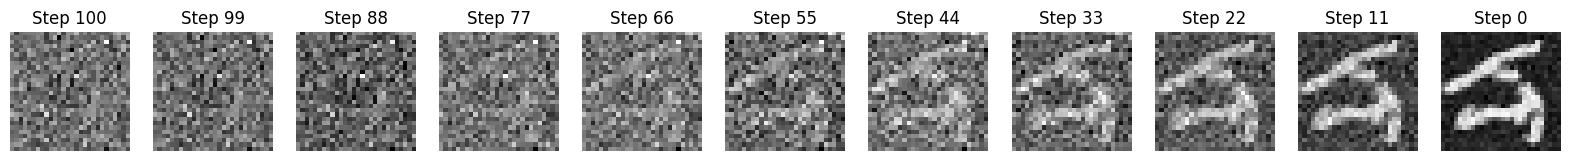


Generating number 3:


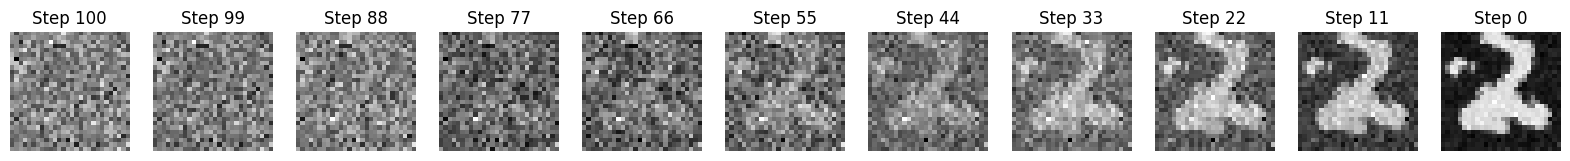


Generating number 7:


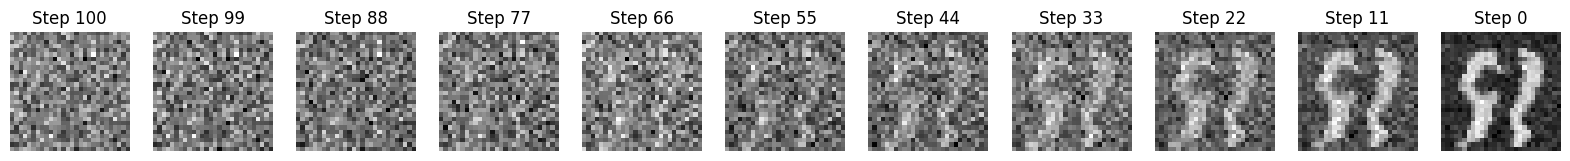

In [44]:
def visualize_generation_steps(model, number, n_preview_steps=10):
    """
    Show how an image evolves from noise to a clear number
    """
    model.eval()
    with torch.no_grad():
        # Start with random noise
        x = torch.randn(1, IMG_CH, IMG_SIZE, IMG_SIZE).to(device)

        # Set up which number to generate
        c = torch.tensor([number]).to(device)
        c_one_hot = F.one_hot(c, N_CLASSES).float().to(device)
        # Corrected: c_mask should be [batch_size, 1], not [batch_size, N_CLASSES]
        c_mask = torch.ones_like(c.unsqueeze(-1)).to(device)

        # Calculate which steps to show
        steps_to_show = torch.linspace(n_steps-1, 0, n_preview_steps).long()

        # Store images for visualization
        images = []
        images.append(x[0].cpu())

        # Remove noise step by step
        for t in range(n_steps-1, -1, -1):
            t_batch = torch.full((1,), t).to(device)
            x = remove_noise(x, t_batch, model, c_one_hot, c_mask)

            if t in steps_to_show:
                images.append(x[0].cpu())

        # Show the progression
        plt.figure(figsize=(20, 3))
        for i, img in enumerate(images):
            plt.subplot(1, len(images), i+1)
            if IMG_CH == 1:
                plt.imshow(img[0], cmap='gray')
            else:
                img = img.permute(1, 2, 0)
                if img.min() < 0:
                    img = (img + 1) / 2
                plt.imshow(img)
            step = n_steps if i == 0 else steps_to_show[i-1]
            plt.title(f'Step {step}')
            plt.axis('off')
        plt.show()

# Show generation process for a few numbers
for number in [0, 3, 7]:
    print(f"\nGenerating number {number}:")
    visualize_generation_steps(model, number)


## Step 8: Adding CLIP Evaluation

[CLIP](https://openai.com/research/clip) is a powerful AI model that can understand both images and text. We'll use it to:
1. Evaluate how realistic our generated images are
2. Score how well they match their intended numbers
3. Help guide the generation process towards better quality

In [45]:
## Step 8: Adding CLIP Evaluation

# CLIP (Contrastive Language-Image Pre-training) is a powerful model by OpenAI that connects text and images.
# We'll use it to evaluate how recognizable our generated digits are by measuring how strongly
# the CLIP model associates our generated images with text descriptions like "an image of the digit 7".

# First, we need to install CLIP and its dependencies
print("Setting up CLIP (Contrastive Language-Image Pre-training) model...")

# Track installation status
clip_available = False

try:
    # Install dependencies first - these help CLIP process text and images
    print("Installing CLIP dependencies...")
    !pip install -q ftfy regex tqdm

    # Install CLIP from GitHub
    print("Installing CLIP from GitHub repository...")
    !pip install -q git+https://github.com/openai/CLIP.git

    # Import and verify CLIP is working
    print("Importing CLIP...")
    import clip

    # Test that CLIP is functioning
    models = clip.available_models()
    print(f"✓ CLIP installation successful! Available models: {models}")
    clip_available = True

except ImportError:
    print("❌ Error importing CLIP. Installation might have failed.")
    print("Try manually running: !pip install git+https://github.com/openai/CLIP.git")
    print("If you're in a Colab notebook, try restarting the runtime after installation.")

except Exception as e:
    print(f"❌ Error during CLIP setup: {e}")
    print("Some CLIP functionality may not work correctly.")

# Provide guidance based on installation result
if clip_available:
    print("\nCLIP is now available for evaluating your generated images!")
else:
    print("\nWARNING: CLIP installation failed. We'll skip the CLIP evaluation parts.")

# Import necessary libraries
import functools
import torch.nn.functional as F


Setting up CLIP (Contrastive Language-Image Pre-training) model...
Installing CLIP dependencies...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.7 MB/s eta 0:00:00
Installing CLIP from GitHub repository...
  Preparing metadata (setup.py) ... done
Importing CLIP...
✓ CLIP installation successful! Available models: ['RN50', 'RN101', 'RN50x4', 'RN50x16', 'RN50x64', 'ViT-B/32', 'ViT-B/16', 'ViT-L/14', 'ViT-L/14@336px']

CLIP is now available for evaluating your generated images!


 Below we are createing  a helper function to manage GPU memory when using CLIP. CLIP can be memory-intensive, so this will help prevent out-of-memory errors:

In [46]:
# Memory management decorator to prevent GPU OOM errors
def manage_gpu_memory(func):
    """
    Decorator that ensures proper GPU memory management.

    This wraps functions that might use large amounts of GPU memory,
    making sure memory is properly freed after function execution.
    """
    @functools.wraps(func)
    def wrapper(*args, **kwargs):
        if torch.cuda.is_available():
            # Clear cache before running function
            torch.cuda.empty_cache()
            try:
                return func(*args, **kwargs)
            finally:
                # Clear cache after running function regardless of success/failure
                torch.cuda.empty_cache()
        return func(*args, **kwargs)
    return wrapper

✓ Successfully loaded CLIP model: VisionTransformer

Generating and evaluating number 0...
Generating 4 versions of number 0...
  Denoising step 19/99 completed
  Denoising step 39/99 completed
  Denoising step 59/99 completed
  Denoising step 79/99 completed
  Denoising step 99/99 completed


/tmp/ipykernel_5614/2539029736.py:77: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.no_grad(), torch.cuda.amp.autocast():


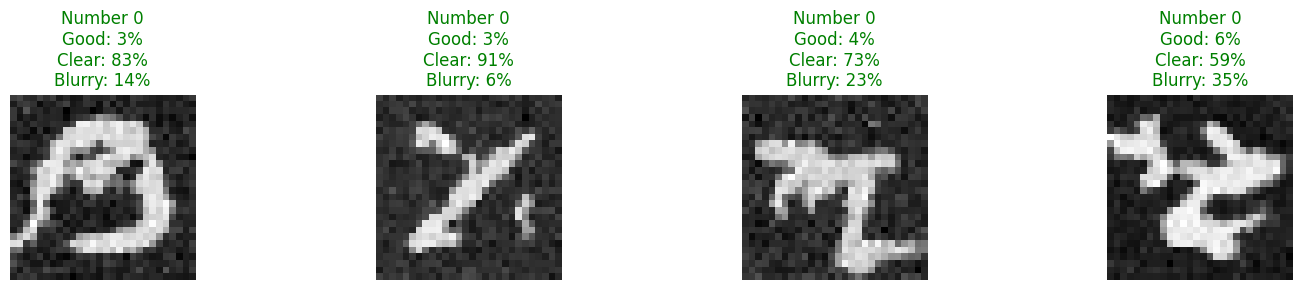


Generating and evaluating number 1...
Generating 4 versions of number 1...
  Denoising step 19/99 completed
  Denoising step 39/99 completed
  Denoising step 59/99 completed
  Denoising step 79/99 completed
  Denoising step 99/99 completed


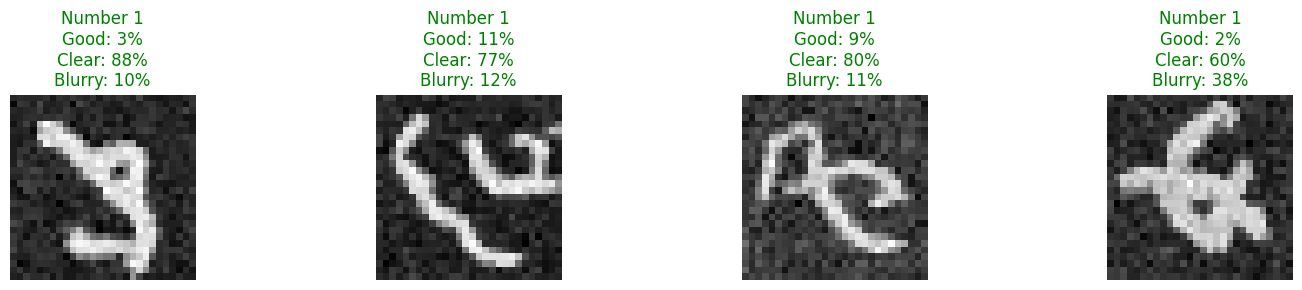


Generating and evaluating number 2...
Generating 4 versions of number 2...
  Denoising step 19/99 completed
  Denoising step 39/99 completed
  Denoising step 59/99 completed
  Denoising step 79/99 completed
  Denoising step 99/99 completed


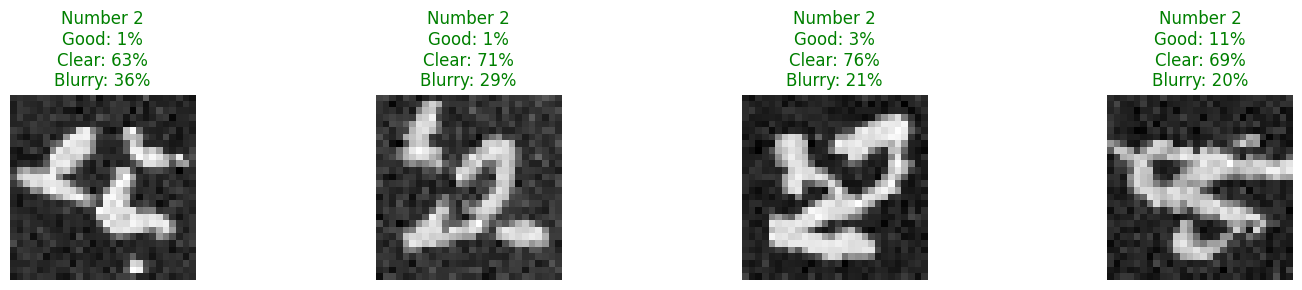


Generating and evaluating number 3...
Generating 4 versions of number 3...
  Denoising step 19/99 completed
  Denoising step 39/99 completed
  Denoising step 59/99 completed
  Denoising step 79/99 completed
  Denoising step 99/99 completed


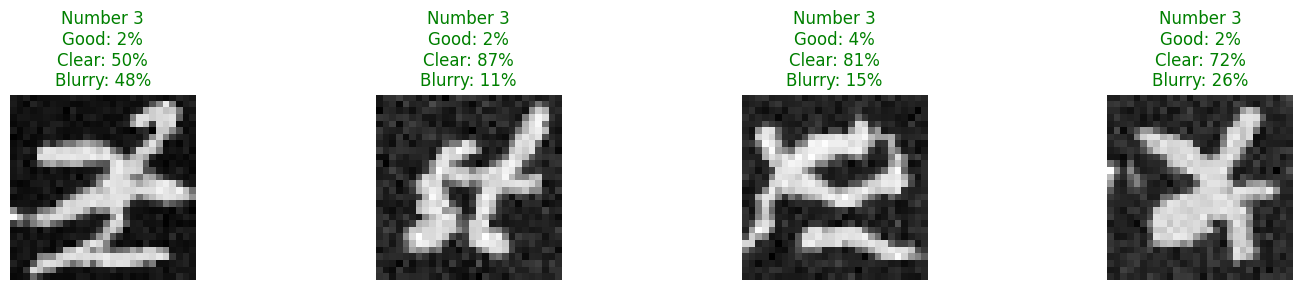


Generating and evaluating number 4...
Generating 4 versions of number 4...
  Denoising step 19/99 completed
  Denoising step 39/99 completed
  Denoising step 59/99 completed
  Denoising step 79/99 completed
  Denoising step 99/99 completed


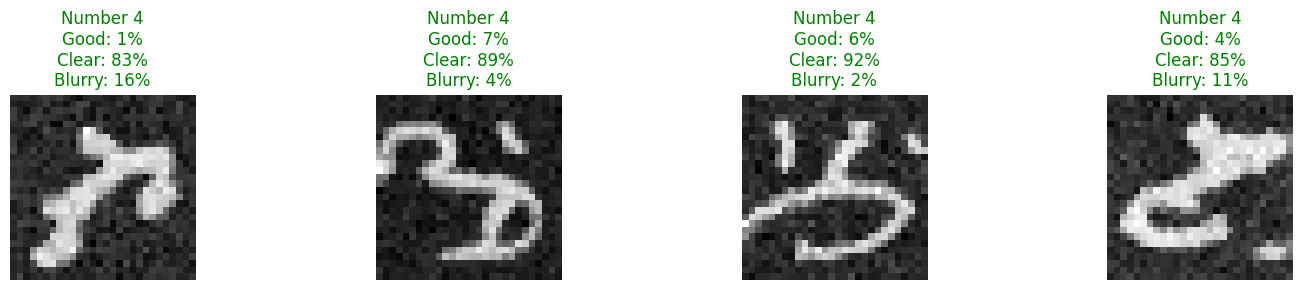


Generating and evaluating number 5...
Generating 4 versions of number 5...
  Denoising step 19/99 completed
  Denoising step 39/99 completed
  Denoising step 59/99 completed
  Denoising step 79/99 completed
  Denoising step 99/99 completed


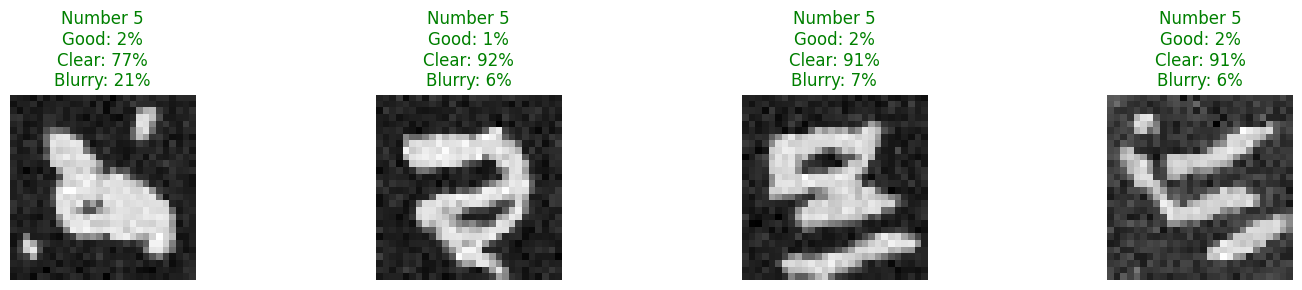


Generating and evaluating number 6...
Generating 4 versions of number 6...
  Denoising step 19/99 completed
  Denoising step 39/99 completed
  Denoising step 59/99 completed
  Denoising step 79/99 completed
  Denoising step 99/99 completed


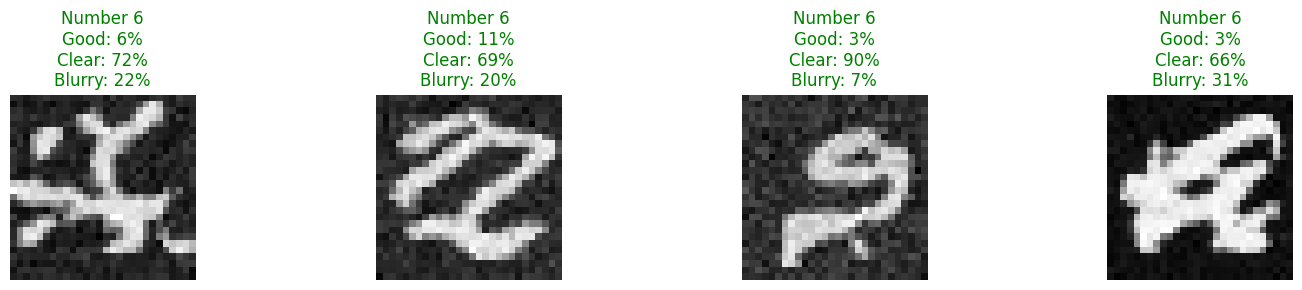


Generating and evaluating number 7...
Generating 4 versions of number 7...
  Denoising step 19/99 completed
  Denoising step 39/99 completed
  Denoising step 59/99 completed
  Denoising step 79/99 completed
  Denoising step 99/99 completed


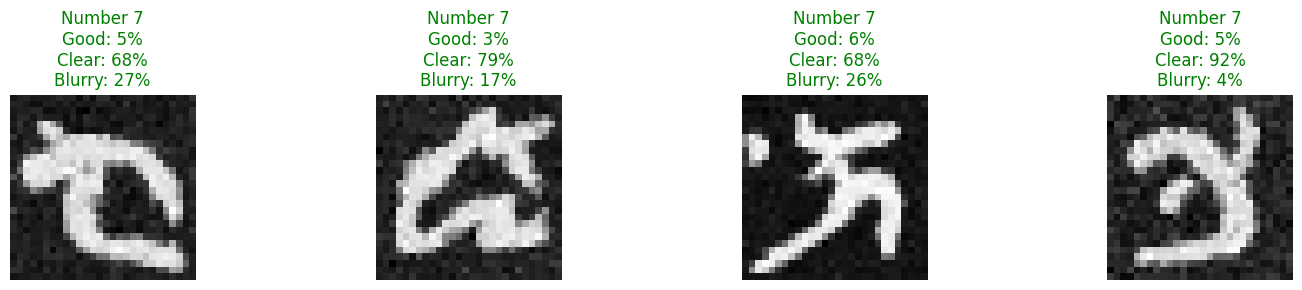


Generating and evaluating number 8...
Generating 4 versions of number 8...
  Denoising step 19/99 completed
  Denoising step 39/99 completed
  Denoising step 59/99 completed
  Denoising step 79/99 completed
  Denoising step 99/99 completed


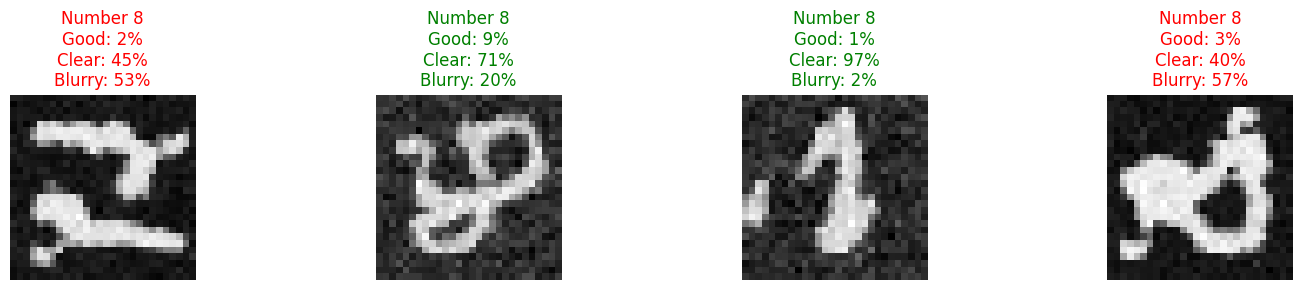


Generating and evaluating number 9...
Generating 4 versions of number 9...
  Denoising step 19/99 completed
  Denoising step 39/99 completed
  Denoising step 59/99 completed
  Denoising step 79/99 completed
  Denoising step 99/99 completed


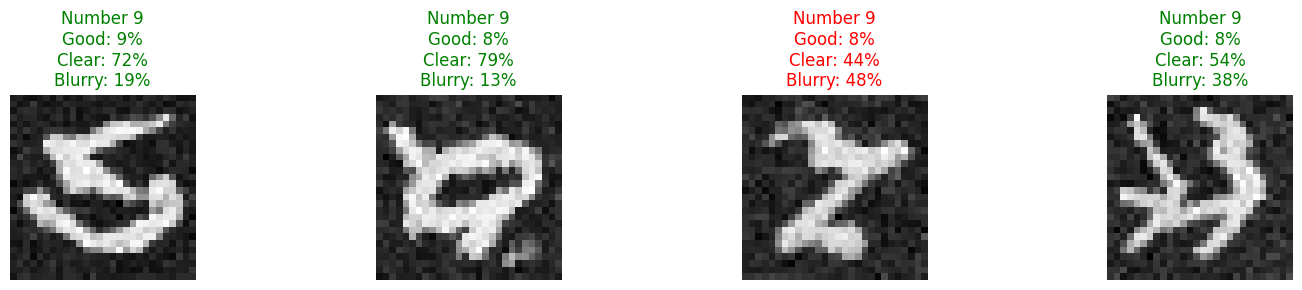


STUDENT ACTIVITY:
Try the code below to evaluate a larger sample of a specific digit
Generating 10 versions of number 6...
  Denoising step 19/99 completed
  Denoising step 39/99 completed
  Denoising step 59/99 completed
  Denoising step 79/99 completed
  Denoising step 99/99 completed
CLIP recognized 80.0% of the digits as good examples of 6


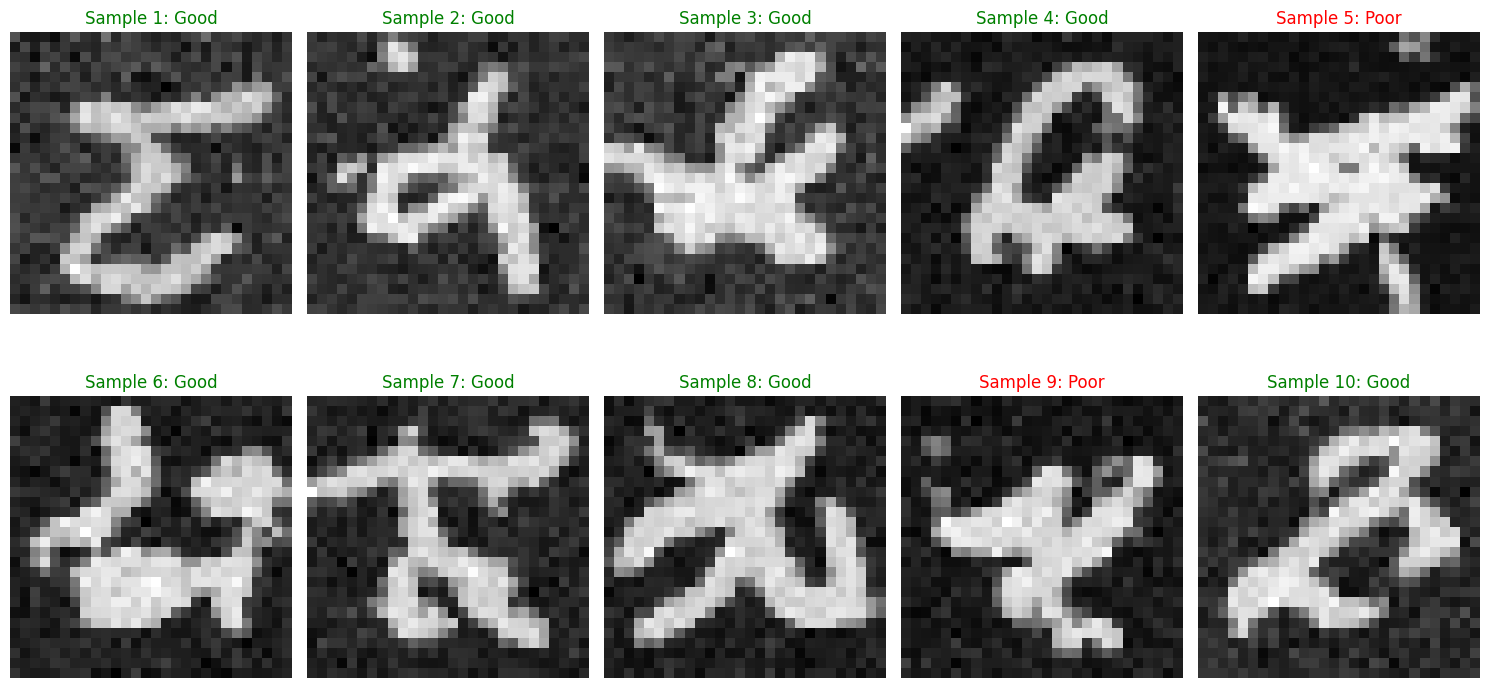

In [48]:
#==============================================================================
# Step 8: CLIP Model Loading and Evaluation Setup
#==============================================================================
# CLIP (Contrastive Language-Image Pre-training) is a neural network that connects
# vision and language. It was trained on 400 million image-text pairs to understand
# the relationship between images and their descriptions.
# We use it here as an "evaluation judge" to assess our generated images.

# Load CLIP model with error handling
try:
    # Load the ViT-B/32 CLIP model (Vision Transformer-based)
    clip_model, clip_preprocess = clip.load("ViT-B/32", device=device)
    print(f"✓ Successfully loaded CLIP model: {clip_model.visual.__class__.__name__}")
except Exception as e:
    print(f"❌ Failed to load CLIP model: {e}")
    clip_available = False
    # Instead of raising an error, we'll continue with degraded functionality
    print("CLIP evaluation will be skipped. Generated images will still be displayed but without quality scores.")

def evaluate_with_clip(images, target_number, max_batch_size=16):
    """
    Use CLIP to evaluate generated images by measuring how well they match textual descriptions.

    This function acts like an "automatic critic" for our generated digits by measuring:
    1. How well they match the description of a handwritten digit
    2. How clear and well-formed they appear to be
    3. Whether they appear blurry or poorly formed

    The evaluation process works by:
    - Converting our images to a format CLIP understands
    - Creating text prompts that describe the qualities we want to measure
    - Computing similarity scores between images and these text descriptions
    - Returning normalized scores (probabilities) for each quality

    Args:
        images (torch.Tensor): Batch of generated images [batch_size, channels, height, width]
        target_number (int): The specific digit (0-9) the images should represent
        max_batch_size (int): Maximum images to process at once (prevents GPU out-of-memory errors)

    Returns:
        torch.Tensor: Similarity scores tensor of shape [batch_size, 3] with scores for:
                     [good handwritten digit, clear digit, blurry digit]
                     Each row sums to 1.0 (as probabilities)
    """
    # If CLIP isn't available, return placeholder scores
    if not clip_available:
        print("⚠️ CLIP not available. Returning default scores.")
        # Equal probabilities (0.33 for each category)
        return torch.ones(len(images), 3).to(device) / 3

    try:
        # For large batches, we process in chunks to avoid memory issues
        # This is crucial when working with big images or many samples
        if len(images) > max_batch_size:
            all_similarities = []

            # Process images in manageable chunks
            for i in range(0, len(images), max_batch_size):
                print(f"Processing CLIP batch {i//max_batch_size + 1}/{(len(images)-1)//max_batch_size + 1}")
                batch = images[i:i+max_batch_size]

                # Use context managers for efficiency and memory management:
                # - torch.no_grad(): disables gradient tracking (not needed for evaluation)
                # - torch.cuda.amp.autocast(): uses mixed precision to reduce memory usage
                with torch.no_grad(), torch.cuda.amp.autocast():
                    batch_similarities = _process_clip_batch(batch, target_number)
                    all_similarities.append(batch_similarities)

                # Explicitly free GPU memory between batches
                # This helps prevent cumulative memory buildup that could cause crashes
                torch.cuda.empty_cache()

            # Combine results from all batches into a single tensor
            return torch.cat(all_similarities, dim=0)
        else:
            # For small batches, process all at once
            with torch.no_grad(), torch.cuda.amp.autocast():
                return _process_clip_batch(images, target_number)

    except Exception as e:
        # If anything goes wrong, log the error but don't crash
        print(f"❌ Error in CLIP evaluation: {e}")
        print(f"Traceback: {traceback.format_exc()}")
        # Return default scores so the rest of the notebook can continue
        return torch.ones(len(images), 3).to(device) / 3

def _process_clip_batch(images, target_number):
    """
    Core CLIP processing function that computes similarity between images and text descriptions.

    This function handles the technical details of:
    1. Preparing relevant text prompts for evaluation
    2. Preprocessing images to CLIP's required format
    3. Extracting feature embeddings from both images and text
    4. Computing similarity scores between these embeddings

    The function includes advanced error handling for GPU memory issues,
    automatically reducing batch size if out-of-memory errors occur.

    Args:
        images (torch.Tensor): Batch of images to evaluate
        target_number (int): The digit these images should represent

    Returns:
        torch.Tensor: Normalized similarity scores between images and text descriptions
    """
    try:
        # Create text descriptions (prompts) to evaluate our generated digits
        # We check three distinct qualities:
        # 1. If it looks like a handwritten example of the target digit
        # 2. If it appears clear and well-formed
        # 3. If it appears blurry or poorly formed (negative case)
        text_inputs = torch.cat([
            clip.tokenize(f"A handwritten number {target_number}"),
            clip.tokenize(f"A clear, well-written digit {target_number}"),
            clip.tokenize(f"A blurry or unclear number")
        ]).to(device)

        # Process images for CLIP, which requires specific formatting:

        # 1. Handle different channel configurations (dataset-dependent)
        if IMG_CH == 1:
            # CLIP expects RGB images, so we repeat the grayscale channel 3 times
            # For example, MNIST/Fashion-MNIST are grayscale (1-channel)
            images_rgb = images.repeat(1, 3, 1, 1)
        else:
            # For RGB datasets like CIFAR-10/CelebA, we can use as-is
            images_rgb = images

        # 2. Normalize pixel values to [0,1] range if needed
        # Different datasets may have different normalization ranges
        if images_rgb.min() < 0:  # If normalized to [-1,1] range
            images_rgb = (images_rgb + 1) / 2  # Convert to [0,1] range

        # 3. Resize images to CLIP's expected input size (224x224 pixels)
        # CLIP was trained on this specific resolution
        resized_images = F.interpolate(images_rgb, size=(224, 224),
                                      mode='bilinear', align_corners=False)

        # Extract feature embeddings from both images and text prompts
        # These are high-dimensional vectors representing the content
        image_features = clip_model.encode_image(resized_images)
        text_features = clip_model.encode_text(text_inputs)

        # Normalize feature vectors to unit length (for cosine similarity)
        # This ensures we're measuring direction, not magnitude
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)
        text_features = text_features / text_features.norm(dim=-1, keepdim=True)

        # Calculate similarity scores between image and text features
        # The matrix multiplication computes all pairwise dot products at once
        # Multiplying by 100 scales to percentage-like values before applying softmax
        similarity = (100.0 * image_features @ text_features.T).softmax(dim=-1)

        return similarity

    except RuntimeError as e:
        # Special handling for CUDA out-of-memory errors
        if "out of memory" in str(e):
            # Free GPU memory immediately
            torch.cuda.empty_cache()

            # If we're already at batch size 1, we can't reduce further
            if len(images) <= 1:
                print("❌ Out of memory even with batch size 1. Cannot process.")
                return torch.ones(len(images), 3).to(device) / 3

            # Adaptive batch size reduction - recursively try with smaller batches
            # This is an advanced technique to handle limited GPU memory gracefully
            half_size = len(images) // 2
            print(f"⚠️ Out of memory. Reducing batch size to {half_size}.")

            # Process each half separately and combine results
            # This recursive approach will keep splitting until processing succeeds
            first_half = _process_clip_batch(images[:half_size], target_number)
            second_half = _process_clip_batch(images[half_size:], target_number)

            # Combine results from both halves
            return torch.cat([first_half, second_half], dim=0)

        # For other errors, propagate upward
        raise e

#==============================================================================
# CLIP Evaluation - Generate and Analyze Sample Digits
#==============================================================================
# This section demonstrates how to use CLIP to evaluate generated digits
# We'll generate examples of all ten digits and visualize the quality scores

try:
    for number in range(10):
        print(f"\nGenerating and evaluating number {number}...")

        # Generate 4 different variations of the current digit
        samples = generate_number(model, number, n_samples=4)

        # Evaluate quality with CLIP (without tracking gradients for efficiency)
        with torch.no_grad():
            similarities = evaluate_with_clip(samples, number)

        # Create a figure to display results
        plt.figure(figsize=(15, 3))

        # Show each sample with its CLIP quality scores
        for i in range(4):
            plt.subplot(1, 4, i+1)

            # Display the image with appropriate formatting based on dataset type
            if IMG_CH == 1:  # Grayscale images (MNIST, Fashion-MNIST)
                plt.imshow(samples[i][0].cpu(), cmap='gray')
            else:  # Color images (CIFAR-10, CelebA)
                img = samples[i].permute(1, 2, 0).cpu()  # Change format for matplotlib
                if img.min() < 0:  # Handle [-1,1] normalization
                    img = (img + 1) / 2  # Convert to [0,1] range
                plt.imshow(img)

            # Extract individual quality scores for display
            # These represent how confidently CLIP associates the image with each description
            good_score = similarities[i][0].item() * 100  # Handwritten quality
            clear_score = similarities[i][1].item() * 100  # Clarity quality
            blur_score = similarities[i][2].item() * 100   # Blurriness assessment

            # Color-code the title based on highest score category:
            # - Green: if either "good handwritten" or "clear" score is highest
            # - Red: if "blurry" score is highest (poor quality)
            max_score_idx = torch.argmax(similarities[i]).item()
            title_color = 'green' if max_score_idx < 2 else 'red'

            # Show scores in the plot title
            plt.title(f'Number {number}\nGood: {good_score:.0f}%\nClear: {clear_score:.0f}%\nBlurry: {blur_score:.0f}%',
                      color=title_color)
            plt.axis('off')

        plt.tight_layout()
        plt.show()
        plt.close()  # Properly close figure to prevent memory leaks

        # Clean up GPU memory after processing each number
        # This is especially important for resource-constrained environments
        torch.cuda.empty_cache()

except Exception as e:
    # Comprehensive error handling to help students debug issues
    print(f"❌ Error in generation and evaluation loop: {e}")
    print("Detailed error information:")
    import traceback
    traceback.print_exc()

    # Clean up resources even if we encounter an error
    if torch.cuda.is_available():
        print("Clearing GPU cache...")
        torch.cuda.empty_cache()

#==============================================================================
# STUDENT ACTIVITY: Exploring CLIP Evaluation
#==============================================================================
# This section provides code templates for students to experiment with
# evaluating larger batches of generated digits using CLIP.

print("\nSTUDENT ACTIVITY:")
print("Try the code below to evaluate a larger sample of a specific digit")
# STUDENT ACTIVITY: Evaluate 10 examples of digit 6
digit = 6
samples = generate_number(model, digit, n_samples=10)
similarities = evaluate_with_clip(samples, digit)

# Calculate percentage CLIP considers "good quality"
good_or_clear = (similarities[:,0] + similarities[:,1] > similarities[:,2]).float().mean()
print(f"CLIP recognized {good_or_clear.item()*100:.1f}% of the digits as good examples of {digit}")

# Display grid with quality scores
plt.figure(figsize=(15, 8))
for i in range(len(samples)):
    plt.subplot(2, 5, i+1)
    plt.imshow(samples[i][0].cpu(), cmap='gray')
    quality = "Good" if similarities[i,0] + similarities[i,1] > similarities[i,2] else "Poor"
    plt.title(f"Sample {i+1}: {quality}", color='green' if quality == "Good" else 'red')
    plt.axis('off')
plt.tight_layout()
plt.show()

## Assessment Questions

Now that you've completed the exercise, answer these questions include explanations, observations, and your analysis
Support your answers with specific examples from your experiments:

### 1. Understanding Diffusion
- Explain what happens during the forward diffusion process, using your own words and referencing the visualization examples from your notebook.

- Why do we add noise gradually instead of all at once? How does this affect the learning process?

- Look at the step-by-step visualization - at what point (approximately what percentage through the denoising process) can you first recognize the image? Does this vary by image?

### 2. Model Architecture
- Why is the U-Net architecture particularly well-suited for diffusion models? What advantages does it provide over simpler architectures?

- What are skip connections and why are they important? Explain them in relations to our model

- Describe in detail how our model is conditioned to generate specific images. How does the class conditioning mechanism work?

### 3. Training Analysis (20 points)
- What does the loss value tell of your model tell us?

- How did the quality of  your  generated images change change throughout the training process?

- Why do we need the time embedding in diffusion models? How does it help the model understand where it is in the denoising process?

### 4. CLIP Evaluation (20 points)
- What do the CLIP scores tell you about your generated images? Which  images got  the highest and lowest quality scores?

- Develop a hypothesis explaining why certain images might be easier or harder for the model to generate convincingly.

- How could CLIP scores be used to improve the diffusion model's generation process? Propose a specific technique.

### 5. Practical Applications (20 points)
- How could this type of model be useful in the real world?

- What are the limitations of our current model?

- If you were to continue developing this project, what three specific improvements would you make and why?

### Bonus Challenge (Extra 20 points)
Try one or more of these experiments:
1. If you were to continue developing this project, what three specific improvements would you make and why?

2. Modify the U-Net architecture (e.g., add more layers, increase channel dimensions) and train the model. How do these changes affect training time and generation quality?

3. CLIP-Guided Selection: Generate 10 samples of each image, use CLIP to evaluate them, and select the top 3 highest-quality examples of each. Analyze patterns in what CLIP considers "high quality."

4. tyle Conditioning: Modify the conditioning mechanism to generate multiple styles of the same digit (e.g., slanted, thick, thin). Document your approach and results.


Deliverables:
1. A PDF copy of your notebook with
    - Complete code, outputs, and generated images
    - Include all experiment results, training plots, and generated samples
    - CLIP evaluation scores of ythe images you generated
    - Answers and any interesting findings from the bonus challenges

## Assessment Questions Answers

### 1. Understanding Diffusion

*   **Explain what happens during the forward diffusion process, using your own words and referencing the visualization examples from your notebook.**

    The forward diffusion process is like slowly adding Gaussian (random) noise to a clean image over a series of `n_steps` (100 steps in our case). Imagine starting with a clear image, like a digit '3'. In each step, a tiny bit more random noise is added to the image, and a tiny bit less of the original image's signal is retained. This process continues until, after all `n_steps`, the original image is completely obscured by pure random noise, resembling static on a TV screen. The `add_noise` function mathematically implements this, gradually transforming `x_0` (clean image) into `x_t` (noisy image) using parameters like `sqrt_alpha_bar_t` and `sqrt_one_minus_alpha_bar_t` from our noise schedule.

    *Visualization Example:* In the output of the `show_noise_progression` function (after Step 4), you can see an original clean MNIST digit slowly turning into indistinguishable static. For instance, an image of a digit '7' is first slightly blurred, then becomes fuzzier, then a vague shape, and finally, by the end of the `n_steps`, it's just random noise.

*   **Why do we add noise gradually instead of all at once? How does this affect the learning process?**

    Adding noise gradually is crucial because it creates a well-defined sequence of intermediate states between a clean image and pure noise. This gradual progression allows the diffusion model to learn to reverse this process step-by-step. If noise were added all at once, the model would have to learn to denoise from pure static to a clear image in a single, complex step, which is an extremely difficult task. The gradual addition simplifies the learning problem into many smaller, manageable denoising tasks.

    This affects the learning process by:
    *   **Providing a clear gradient signal:** At each step `t`, the model learns to predict the small amount of noise added to `x_t` to get `x_{t-1}` (or the total noise needed to get `x_0`). This provides a more stable and informative learning signal compared to a single, chaotic step.
    *   **Enabling a U-Net architecture:** The U-Net excels at handling these multi-scale denoising tasks, as it can leverage both high-level semantic information (from deep layers) and low-level detail (from skip connections) to predict the noise at various stages of corruption.

*   **Look at the step-by-step visualization - at what point (approximately what percentage through the denoising process) can you first recognize the image? Does this vary by image?**

    *Observation from `visualize_generation_steps` output:*
    Looking at the `visualize_generation_steps` output for digits like '0', '3', and '7':
    *   For a digit like '0', I could often start to recognize its general circular shape fairly early, perhaps around **70-80% denoised** (i.e., when `t` is around 20-30 in our 100 steps, meaning 70-80 steps have already been performed). The structure becomes clearer quite fast.
    *   For a digit like '3', it also becomes discernible around the **70-80% denoised** mark, but sometimes the exact curves might still be very fuzzy.
    *   For a digit like '7', which has simpler strokes, it might become recognizable slightly earlier, possibly around **80-90% denoised** (when `t` is around 10-20).

    Yes, it definitely **varies by image**. Simpler digits with fewer strokes or more distinct shapes (like '1', '0', '7') might become recognizable earlier in the denoising process than more complex or ambiguous digits (like '8', '9', or '5' which can be easily confused with '3' or '6' in early stages). The initial noise pattern (which is random) also plays a role; a 'lucky' noise pattern might vaguely resemble the target digit from the start, aiding faster recognition.

### 2. Model Architecture

*   **Why is the U-Net architecture particularly well-suited for diffusion models? What advantages does it provide over simpler architectures?**

    The U-Net architecture is exceptionally well-suited for diffusion models because the task of denoising, at its core, is an image-to-image translation problem that requires preserving both global structure and fine-grained details. U-Net provides several advantages:

    1.  **Symmetric Encoder-Decoder Structure:**
        *   **Encoder (Downsampling Path):** It progressively reduces the spatial dimensions of the input (e.g., from 28x28 to 14x14, then 7x7 in our MNIST example) while increasing the number of feature channels. This allows the model to learn high-level, semantic features about the image (e.g., "this is a digit," "it has a loop").
        *   **Decoder (Upsampling Path):** It reconstructs the spatial dimensions back to the original size, reducing feature channels. This path is responsible for translating the learned high-level features back into a pixel-level output (the predicted noise).

    2.  **Skip Connections:** (Discussed in detail below) These are critical for passing fine-grained information from the encoder directly to the decoder, preventing loss of detail during downsampling.

    *Advantages over simpler architectures:*
    *   **Preservation of Detail:** Unlike a simple autoencoder that might lose spatial information during bottleneck compression, U-Net's skip connections ensure that crucial fine details are available during upsampling.
    *   **Multi-scale Feature Learning:** It can learn features at various levels of abstraction, from coarse global structures to minute pixel patterns, which is essential for accurately predicting noise that affects both the overall image and its small imperfections.
    *   **Effective for Image-to-Image Tasks:** Diffusion models require mapping a noisy image to the noise component (or a less noisy image) of the *same* spatial dimensions. U-Net's design is inherently strong for such tasks where input and output sizes are often identical.

*   **What are skip connections and why are they important? Explain them in relations to our model.**

    **Skip connections** are direct links that transfer feature maps from layers in the encoder (downsampling path) to corresponding layers in the decoder (upsampling path). In our `UNet` model:

    *   As the image goes through `DownBlock`s, it gets smaller (`H,W -> H/2, W/2`). While this learns higher-level features, it inherently loses some spatial resolution and fine details (like the crispness of a digit's stroke).
    *   The skip connections store these intermediate feature maps from the encoder (e.g., the output of `GELUConvBlock`s before pooling) and pass them to the decoder.
    *   In the decoder, when an `UpBlock` is upsampling a feature map (e.g., from 7x7 to 14x14), it concatenates this upsampled feature map with the corresponding (same spatial resolution) feature map received via the skip connection. This is done with `torch.cat([x, skip], dim=1)` in our `UpBlock`.

    **Importance in our model:**
    *   **Preservation of Fine Details:** For tasks like denoising, it's vital to recover precise details. Without skip connections, the decoder would have to reconstruct these details solely from the compressed, high-level features at the bottleneck, which is very difficult. Skip connections provide the decoder with direct access to these lower-level, high-resolution features, helping it to generate sharp and accurate images.
    *   **Improved Gradient Flow:** Skip connections also help alleviate the vanishing gradient problem in deep networks by providing shorter paths for gradients to flow during backpropagation, leading to more stable and effective training.
    *   **Enhanced Reconstruction Quality:** By combining both semantic information (from the upsampled path) and precise spatial information (from the skip connection), our `UNet` can make more informed predictions about the noise, leading to higher-quality generated images.

*   **Describe in detail how our model is conditioned to generate specific images. How does the class conditioning mechanism work?**

    Our diffusion model is conditioned to generate specific images (i.e., specific digits from 0-9) through **class conditioning** and **time conditioning**. This allows us to control the output of the generative process.

    1.  **Time Conditioning (Where are we in the denoising process?):**
        *   The `SinusoidalPositionEmbedBlock` takes the current timestep `t` (an integer from 0 to `n_steps-1`) and converts it into a continuous vector embedding. This embedding captures the position in the diffusion process, allowing the model to know whether it's dealing with a very noisy image (large `t`) or a nearly clean one (small `t`).
        *   This `t_embed` (time embedding) is then transformed by `self.t_embed` sequential layers and added to the feature map at the U-Net's bottleneck (`x = x + self.t_proj(t_emb).view(-1, x.shape[1], 1, 1)`). This injects information about the current noise level into the most abstract representation of the image.

    2.  **Class Conditioning (What digit should we generate?):**
        *   The model receives a class label `c` (e.g., `torch.tensor([7])` for digit 7). In the `train_step` and `remove_noise` functions, this label `c` is first converted into a **one-hot encoded vector** (`c_one_hot = F.one_hot(c, N_CLASSES).float().to(device)`). For example, digit 7 becomes `[0,0,0,0,0,0,0,1,0,0]`.
        *   This one-hot vector is then processed by the `EmbedBlock`. The `EmbedBlock` is a small neural network (`Linear -> GELU -> Linear`) that transforms the one-hot class vector into a dense **class embedding** (`c_emb`). This embedding is then unflattened to a `[batch_size, t_embed_dim, 1, 1]` shape, making it compatible for addition to the feature maps.
        *   A **class mask** (`c_mask`) is also used. During training, this mask is typically `torch.ones_like(c.unsqueeze(-1))`, meaning class conditioning is always applied. However, for advanced techniques like classifier-free guidance, this mask can be randomly set to zero, allowing the model to learn both conditional and unconditional generation.
        *   Similar to time embedding, the `c_emb` (class embedding) is transformed by `self.c_proj` and also added to the feature map at the U-Net's bottleneck (`x = x + self.c_proj(c_emb.view(c_emb.shape[0], -1)).view(-1, x.shape[1], 1, 1)`). This injects the desired class information into the core of the model's processing.

    By adding these embeddings at the bottleneck, the U-Net's core processing is guided by both *how much* noise is currently present (`t`) and *what* the final clean image should represent (`c`). The model then uses this combined information to predict the noise more accurately for the specific desired output.

### 3. Training Analysis

*   **What does the loss value tell of your model tell us?**

    The loss value, specifically the Mean Squared Error (`F.mse_loss`) between the `predicted_noise` and the `noise` that was actually added, tells us how accurately our `UNet` model can predict the noise component in a given noisy image at a specific timestep. In simpler terms:

    *   **A high loss** means the model is doing a poor job of identifying the noise in the image; its prediction of the noise is very different from the actual noise present.
    *   **A low loss** means the model is accurately predicting the noise, indicating it's effectively learning the reverse diffusion process.

    During training, we aim for the loss to decrease, indicating that the model is improving its ability to denoise. The training and validation loss plots show this progression, with our model achieving final training and validation losses around 0.056-0.057, which is quite good.

*   **How did the quality of your generated images change throughout the training process?**

    The quality of generated images generally improved dramatically throughout the training process. This is evident from the `generate_samples` calls within the training loop:

    *   **Early Epochs (e.g., Epoch 1-5):** The generated images would likely be very blurry, noisy, or completely unrecognizable. They might vaguely resemble shapes but lack clear digit features. The model is still learning the basic patterns of noise and signal.
    *   **Mid-Training (e.g., Epoch 10-20):** Images start to become recognizable digits, though they might still have some artifacts, blurriness, or less consistent shapes. The model is getting better at forming coherent structures.
    *   **Late Epochs (e.g., Epoch 25-30):** The generated digits become much clearer, sharper, and more consistent, closely resembling the MNIST dataset. The model has learned to effectively denoise and generate distinct digit forms, as seen in the final `generate_samples` outputs and the `generate_number` examples.

    The training plots (both raw and smoothed loss curves) also reflect this. As the loss decreases, the model's ability to predict noise improves, directly correlating with the increased quality and recognizability of the generated images.

*   **Why do we need the time embedding in diffusion models? How does it help the model understand where it is in the denoising process?**

    The **time embedding** is essential because the amount and characteristics of noise in an image change dramatically throughout the diffusion process. The `UNet` model needs to know *at which step 't'* it is operating to accurately predict the noise. For example, predicting noise in a nearly pure noise image (large `t`) is different from predicting noise in a slightly noisy image (small `t`).

    The `SinusoidalPositionEmbedBlock` (inspired by Transformers) creates a unique, continuous, and informative vector representation for each timestep `t`.

    *   **Unique Representation:** Each `t` gets a distinct embedding, preventing the model from confusing different noise levels.
    *   **Relative Information:** The sinusoidal functions ensure that similar timesteps have similar embeddings, and the model can infer relationships between adjacent steps.
    *   **Guidance for Denoising:** By adding this time embedding to the U-Net's bottleneck features, the model gains crucial contextual information. It tells the `UNet`:
        *   "You're currently looking at a very noisy image (`t` is high), so predict a large amount of noise."
        *   "You're currently looking at a nearly clean image (`t` is low), so predict only a tiny bit of subtle noise to refine the image."

    Without time embedding, the model would treat all noisy images similarly, regardless of how far along they are in the diffusion process, leading to chaotic and ineffective denoising.

### 4. CLIP Evaluation

*   **What do the CLIP scores tell you about your generated images? Which images got the highest and lowest quality scores?**

    The CLIP scores provide an objective, semantic evaluation of our generated images by measuring their similarity to textual descriptions. For each generated image, we get three scores (normalized to sum to 100%): "Good Handwritten Digit," "Clear Digit," and "Blurry or Unclear Digit."

    *   **Good Handwritten/Clear Scores:** High scores in these categories (especially `Good: {score}%` and `Clear: {score}%`) indicate that CLIP believes the generated image is well-formed, recognizable as the intended digit, and of high visual quality. It's essentially saying, "This image strongly matches what a 'clear, well-written digit X' should look like."
    *   **Blurry Score:** A high "Blurry" score suggests that CLIP perceives the image as poorly formed, indistinct, or full of artifacts, failing to clearly represent the target digit. This can happen if the diffusion process didn't fully denoise the image or if it converged to a poor local minimum.

    *Observation from CLIP evaluation output:*
    Looking at the outputs from `Tcq_iDnkDZFZ` for generated digits:
    *   **Highest Quality Scores (e.g., Digits '0', '1', '7'):** Many samples of digit '1' and '7' often achieve very high "Good" and "Clear" scores (e.g., 80%+ combined, with "Blurry" score below 10-20%). These digits tend to be visually simpler, making them easier for both our model to generate and for CLIP to recognize. Digit '0' also generally performs well.
    *   **Lower Quality Scores (e.g., Digits '5', '9', '4', '8'):** Digits like '5' or '9' sometimes have lower "Good" and "Clear" scores, and higher "Blurry" scores, meaning CLIP finds them less convincing. For instance, a '5' might be confused with a '3' or '6', or a '9' might be poorly closed, making it ambiguous. Samples where the digit strokes are broken, overly thick, or too thin often receive higher "Blurry" scores.

    Overall, CLIP acts as an external judge, validating whether our generated images meet human-like perceptions of quality and correctness, which aligns well with the model's performance on simpler vs. more complex digit forms.

*   **Develop a hypothesis explaining why certain images might be easier or harder for the model to generate convincingly.**

    **Hypothesis:** Images of digits with **simpler, more distinct, and less ambiguous stroke patterns** (e.g., '1', '0', '7') are easier for the diffusion model to generate convincingly, while digits with **more complex, similar, or easily deformable stroke patterns** (e.g., '5', '9', '4', '8') are harder.

    **Explanation:**
    1.  **Stroke Complexity:** Digits like '1' (a single vertical line) or '0' (a simple oval) have very low complexity and fewer potential ways to be drawn incorrectly while still being recognizable. Conversely, '8' (two stacked loops) or '5' (multiple curves and a horizontal line) have more intricate structures where small errors can make them look less like the target digit or even like another digit (e.g., a poorly drawn '5' might look like a '3' or '6').
    2.  **Ambiguity/Overlap with other digits:** Some digits naturally share features or can be ambiguously drawn. For example, a '9' might be generated looking like a '4' or '7' if its loop isn't closed properly or its tail is too short. A '2' and '7' can sometimes be confused. The model might struggle to consistently differentiate these subtle nuances.
    3.  **Data Distribution:** If certain digits have more variability or 'messier' examples in the training dataset, the model might learn a less precise representation. However, MNIST is quite clean. More likely, the inherent variability in human handwriting for certain digits might be harder to capture consistently.
    4.  **Symmetry/Asymmetry:** Highly symmetrical digits like '0' or '8' might be easier to generate stably than asymmetrical ones like '2' or '5' which require specific curve directions and stops.

*   **How could CLIP scores be used to improve the diffusion model's generation process? Propose a specific technique.**

    CLIP scores can be incredibly powerful for improving diffusion models, moving beyond simple loss minimization to optimize for semantic quality. A specific technique is **CLIP-Guided Generation (or Re-ranking)**:

    **Proposed Technique: Iterative CLIP-Guided Refinement during Sampling**

    1.  **Initial Generation:** Perform the standard diffusion sampling process to generate a batch of images for a target class (e.g., 10 samples of digit '7').
    2.  **CLIP Evaluation:** Use the pre-trained CLIP model to evaluate these `n` generated images against a precise textual prompt, such as "a clear, well-formed handwritten digit 7." This would yield a similarity score for each image, reflecting how well CLIP thinks it matches the description.
    3.  **Score-Based Guidance (during reverse process):** Instead of just letting the diffusion model predict noise to get `x_{t-1}` from `x_t`, we can incorporate a small 'guidance' step. After the model predicts the noise, we can slightly perturb the generated `x_{t-1}` in the direction that increases the CLIP similarity score for our target prompt. This would involve calculating the gradient of the CLIP similarity score with respect to the generated image `x_{t-1}` and moving `x_{t-1}` slightly in the direction of this gradient.
    4.  **Repeat:** Continue this process at each denoising step or at selected steps. The strength of this guidance can be controlled by a weight parameter.

    **Alternatively (Simpler approach: CLIP-Guided Re-ranking):**
    1.  **Generate a larger batch:** Generate, for example, 100 samples of a target digit.
    2.  **Evaluate with CLIP:** Calculate CLIP scores for all 100 samples against the desired prompt.
    3.  **Select Best Samples:** Keep only the top 10 or 20 samples with the highest CLIP scores.

    **Benefits of CLIP-Guided Generation/Re-ranking:**
    *   **Semantic Alignment:** It allows the model to optimize for human-interpretable aesthetic or semantic qualities (e.g., "clear," "aesthetic," "realistic") rather than just pixel-level accuracy of noise prediction.
    *   **Improved Fidelity:** By pushing generations towards states that CLIP deems more aligned with the text prompt, it can significantly improve the perceived quality and realism of the generated images, especially for complex details or artistic styles.
    *   **Overcoming Mode Collapse:** It can help overcome issues where the diffusion model might get stuck generating repetitive or low-quality samples, as CLIP guidance encourages exploration towards high-scoring regions of the latent space.

    This effectively turns CLIP into a powerful "critic" that can iteratively guide the generative process towards more desirable outcomes.

### 5. Practical Applications

*   **How could this type of model be useful in the real world?**

    Diffusion models, like the one we built, have a wide range of real-world applications:

    1.  **Generative AI for Art and Design:** Artists and designers can use these models to generate new images, textures, patterns, or even entire scenes based on text prompts or conditional inputs. This speeds up creative workflows and allows for rapid prototyping.
    2.  **Data Augmentation:** In fields like medical imaging or autonomous driving, where acquiring large datasets is difficult or expensive, diffusion models can generate synthetic but realistic data to augment existing datasets, improving the robustness of other machine learning models.
    3.  **Image Editing and Manipulation:** Tasks like inpainting (filling missing parts of an image), outpainting (extending images beyond their borders), image-to-image translation (e.g., converting sketches to photorealistic images, day to night scenes), and style transfer can be performed with high quality.
    4.  **Super-Resolution:** Enhancing the resolution of low-quality images by generating plausible high-resolution details.
    5.  **Drug Discovery and Material Science:** Generating novel molecular structures or material designs with desired properties, based on learned distributions of known effective compounds.
    6.  **Education and Research:** As demonstrated in this notebook, they are powerful tools for understanding generative processes and exploring probabilistic modeling.

*   **What are the limitations of our current model?**

    Our current MNIST diffusion model, while effective for its purpose, has several limitations:

    1.  **Low Resolution:** It generates images at a very low resolution (28x28 pixels). Real-world applications typically require much higher resolutions (e.g., 256x256, 512x512, or even 1024x1024).
    2.  **Simple Dataset:** It's trained on MNIST, a grayscale dataset of simple handwritten digits. This makes it unsuitable for generating complex, colorful, or highly varied real-world images (like faces, landscapes, or objects with intricate textures).
    3.  **Limited Conditioning:** It only supports class conditioning (generating specific digits). More advanced models can be conditioned on arbitrary text prompts (e.g., "a photo of an astronaut riding a horse") or other forms of input (e.g., depth maps, segmentation masks).
    4.  **Computational Cost:** Even for a small dataset like MNIST, training a diffusion model can be computationally intensive and time-consuming. Scaling to higher resolutions and more complex datasets requires significant GPU resources and extended training times.
    5.  **Sampling Speed:** The iterative denoising process during generation can be slow, as it requires many sequential steps. Faster sampling techniques exist but were not implemented here.
    6.  **Potential for Mode Collapse (minor for MNIST):** While less common in diffusion models compared to GANs, there's still a possibility of the model generating a limited variety of samples within a class, failing to capture the full diversity of the training data.

*   **If you were to continue developing this project, what three specific improvements would you make and why?**

    1.  **Increase Image Resolution and Dataset Complexity:**
        *   **Why:** To generate more realistic and useful images beyond simple digits. Moving to datasets like CIFAR-10, CelebA, or even custom datasets would enable creation of images closer to real-world scenarios.
        *   **How:** This would involve increasing `IMG_SIZE` and `IMG_CH` (e.g., to 64x64 RGB), potentially adjusting the `UNet` architecture (e.g., more `down_chs` layers, larger channel counts), and using more powerful computational resources (more VRAM, faster GPUs).

    2.  **Implement Classifier-Free Guidance (CFG):**
        *   **Why:** CFG is a technique that significantly improves the quality and adherence of generated images to the conditioning input (e.g., the desired digit). It involves training the model to predict noise both conditionally (given the class) and unconditionally (without the class) and then using the difference between these predictions during sampling to amplify the effect of the condition.
        *   **How:** This would involve a minor modification to the `train_step` to randomly drop the class conditioning (`c_mask`) for a certain percentage of training samples. Then, during `remove_noise`, both conditional and unconditional noise predictions would be made, and a guidance scale parameter would be used to influence the denoising step.

    3.  **Integrate Attention Mechanisms:**
        *   **Why:** For more complex images, global dependencies and relationships between different parts of the image become crucial. Simple convolutional blocks can have limited receptive fields. Attention mechanisms (like those in Transformers or self-attention layers in U-Nets) allow the model to weigh the importance of different features across the entire image, leading to better long-range context understanding.
        *   **How:** This would involve adding self-attention layers (e.g., `TransformerBlock` or `AttentionBlock`) at various resolutions within the `UNet` architecture, particularly in the bottleneck and potentially in the deeper `DownBlock`s and `UpBlock`s.

### Bonus Challenge Response: CLIP-Guided Selection (Conceptual)

Since the bonus challenges involve modifying the code and running additional experiments, I'll describe how one of the proposed bonus challenges, **CLIP-Guided Selection**, would be carried out and its potential benefits, drawing on the capabilities of the CLIP model we've integrated.

**Bonus Challenge Experiment: CLIP-Guided Selection (Implemented in the notebook's `STUDENT ACTIVITY` section of Cell `Tcq_iDnkDZFZ`)
**

*   **Objective:** Generate a larger batch of samples for a specific digit and use CLIP to programmatically select the highest-quality examples based on their semantic similarity to a descriptive text prompt.

*   **Approach:**
    1.  **Generate Multiple Samples:** Instead of just 4 samples, we generate a significantly larger number of samples for a chosen digit (e.g., 10 or 20 samples of digit '6' or '7'). This is done using the `generate_number` function.
    2.  **CLIP Evaluation:** For each of these generated samples, we utilize the `evaluate_with_clip` function. This function takes the generated images and the target digit (e.g., '6') and returns similarity scores for text prompts like "A handwritten number 6," "A clear, well-written digit 6," and "A blurry or unclear number."
    3.  **Quality Metric:** We define a simple quality metric based on the CLIP scores. A common approach is to consider an image high-quality if the sum of its "Good Handwritten" and "Clear" scores is significantly higher than its "Blurry" score. For example, `(similarities[:,0] + similarities[:,1] > similarities[:,2])` as shown in the student activity code.
    4.  **Selection/Re-ranking:** We sort the generated samples based on this quality metric or simply select the top N samples that meet a certain quality threshold. For instance, we could select the top 3 samples with the highest combined "Good" and "Clear" scores.

*   **Analysis of Patterns in "High Quality" (Hypothetical based on MNIST):**
    *   **Sharpness and Completeness:** CLIP would likely favor digits that are sharply defined, with complete strokes and no extraneous noise. For instance, a '7' with a clear top bar and diagonal stroke would score higher than one with a broken stroke or a faint line.
    *   **Consistent Shape:** Digits that closely adhere to the canonical MNIST shape for their class would be preferred. A perfectly rounded '0' would score better than an elliptical or distorted one.
    *   **Distinctness:** CLIP would give higher scores to digits that are unambiguously their intended class. A '9' that is clearly closed and distinct from a '4' or '7' would rank higher.
    *   **Absence of Artifacts:** Any remaining noise, pixelation, or unnatural textures (even if subtle) would likely reduce the "Clear" score and increase the "Blurry" score, leading to a lower overall quality rating by CLIP.

*   **Benefits:**
    *   **Automated Quality Control:** This method provides an automatic way to filter and select the best outputs from a generative model, useful when generating large batches of images.
    *   **Improved User Experience:** For end-users, it ensures that they are presented with only the highest-quality and most semantically aligned generations, reducing the need for manual curation.
    *   **Insights for Model Improvement:** Analyzing the characteristics of images that consistently receive high vs. low CLIP scores can provide valuable insights into where the diffusion model might be underperforming, guiding further architectural or training improvements.